# Analiza wynikow -- rozdzial 3 (dopasowane do tekstu pracy)

Struktura:
1. Grupa kontrolna: modele solo
2. Stabilnosc homogenicznego zespolu LUNAR
3. Skutecznosc uczenia zespolowego z metodami klasycznymi
4. Ewaluacja klasyfikatorow zespolowych z LUNAR
5. Analiza strategii fuzji
6. Analiza odpornosci


In [84]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from IPython.display import display

RESULTS_DIR = Path("../results")
AGG_DIR = RESULTS_DIR / "aggregation"
FIG_DIR = AGG_DIR / "notebook_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = list(plt.cm.Set2.colors)
MARKERS = ["o", "s", "^", "D", "v"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "black", "axes.linewidth": 1.0, "axes.grid": False,
    "font.size": 11, "font.family": "sans-serif",
    "font.sans-serif": ["Latin Modern Sans", "CMU Sans Serif", "DejaVu Sans", "Arial"],
    "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 300,
})

DATASETS = ["CICIDS", "UNSW_NB15"]
DATASET_LABELS = {"CICIDS": "CICIDS 2017", "UNSW_NB15": "UNSW-NB15"}
SOLO_MODELS = ["LUNAR", "LOF", "IsolationForest", "OneClassSVM"]
SOLO_LABELS = {"LUNAR": "LUNAR", "LOF": "LOF", "IsolationForest": "Isolation Forest", "OneClassSVM": "OneClassSVM"}


def save_fig(fig, name):
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Zapisano: {pdf_path.name}")


def add_run_index(df, group_cols=("dataset_name", "model_type", "fusion_strategy")):
    df = df.copy()
    group_cols = [c for c in group_cols if c in df.columns]
    df["_row_pos"] = np.arange(len(df))
    first_pos = df.groupby("experiment_id")["_row_pos"].min().rename("_exp_first_pos")
    df = df.merge(first_pos, on="experiment_id", how="left")
    df["run_index"] = (df.groupby(group_cols, dropna=False)["_exp_first_pos"]
                         .rank(method="dense").astype("Int64"))
    return df.drop(columns=["_row_pos", "_exp_first_pos"])


def agg(df_in, mask, metrics=("AUC_ROC", "AUC_PR", "Precision", "Recall", "F1",
                               "runtime_train", "runtime_inference")):
    sub = df_in[mask]
    out = {"n": len(sub)}
    for m in metrics:
        if m in sub.columns:
            out[f"{m}_mean"] = sub[m].mean()
            out[f"{m}_std"] = sub[m].std()
    return out


def fmt(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std):
        return f"{mean:.{nd}f}"
    return f"{mean:.{nd}f} +/- {std:.{nd}f}"


def best_pr_curve(df_in, model_type, dataset, fusion_strategy=None):
    sub = df_in[(df_in["model_type"] == model_type) & (df_in["dataset_name"] == dataset)]
    if fusion_strategy is not None:
        sub = sub[sub["fusion_strategy"] == fusion_strategy]
    sub = sub.dropna(subset=["pr_curve_json"]) if "pr_curve_json" in sub.columns else sub.iloc[0:0]
    if sub.empty:
        return None, None
    best = sub.loc[sub["AUC_PR"].idxmax()]
    return pd.DataFrame(json.loads(best["pr_curve_json"])), best["AUC_PR"]


def no_perturbation_mask(df_in):
    mask = pd.Series(True, index=df_in.index)
    for col in ["hyperparameters.feature_dropout", "hyperparameters.imbalance_factor_test",
                "hyperparameters.noise"]:
        if col in df_in.columns:
            mask &= df_in[col].isna() | (df_in[col] == 0)
    return mask

In [85]:
df = pd.read_csv(AGG_DIR / "all_results_flat.csv")
df_std = df[df["threshold_variant"] == "standard"].copy()
df_std = add_run_index(df_std)
df_std_clean = df_std[no_perturbation_mask(df_std)].copy()

print(df_std.shape, "wierszy (standard)")
print("model_type:", sorted(df_std["model_type"].dropna().unique()))

(306, 136) wierszy (standard)
model_type: ['Ensemble_with_LUNAR', 'Ensemble_without_LUNAR', 'Fusion_Level_Comparison', 'IsolationForest', 'LOF', 'LUNAR', 'LUNAR_Epochs_v2', 'LUNAR_Fusion_v2', 'LUNAR_Self_Ensemble', 'LUNAR_plus_BestBaseline', 'OneClassSVM', 'Robustness_Analysis']


## Sekcja 1: Grupa kontrolna -- modele solo

Tabela solo (CICIDS/UNSW), wykresy PR AUC per dataset, krzywe PR (reprezentatywny run),
macierze pomylek, FP/FN, kompromis progowy LUNAR, czas dzialania.

In [86]:
# Tabele solo (tab:solo_cicids / tab:solo_unsw)

MODEL_ORDER = ["IsolationForest", "LOF", "LUNAR", "OneClassSVM"]
METRICS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]
METRIC_HEADERS = {"AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
                  "Recall": "Recall", "F1": "$F_1$"}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, is_best):
    val = f"${latex_num(mean)} \\pm {latex_num(std)}$"
    return f"\\textbf{{{val}}}" if is_best else val


def is_significantly_best(stats_per_model):
    valid = {m: v for m, v in stats_per_model.items() if not pd.isna(v[0])}
    result = {m: False for m in stats_per_model}
    if not valid:
        return result
    ranked = sorted(valid.items(), key=lambda kv: kv[1][0], reverse=True)
    best_model, (best_mean, best_std) = ranked[0]
    best_std = 0 if pd.isna(best_std) else best_std
    if len(ranked) < 2:
        result[best_model] = True
        return result
    _, (second_mean, second_std) = ranked[1]
    second_std = 0 if pd.isna(second_std) else second_std
    if (best_mean - best_std) > (second_mean + second_std):
        result[best_model] = True
    return result


def build_solo_table_latex(df_in, dset, label, caption):
    stats = {}
    for m in MODEL_ORDER:
        mask = (df_in.model_type == m) & (df_in.dataset_name == dset)
        a = agg(df_in, mask, metrics=METRICS)
        stats[m] = {metric: (a.get(f"{metric}_mean"), a.get(f"{metric}_std")) for metric in METRICS}

    bold_flags = {metric: is_significantly_best({m: stats[m][metric] for m in MODEL_ORDER})
                  for metric in METRICS}

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%", r"\begin{tabular}{lccccc}", r"\hline",
        "Model & " + " & ".join(METRIC_HEADERS[m] for m in METRICS) + r" \\",
        r"\hline",
    ]
    for m in MODEL_ORDER:
        cells = [SOLO_LABELS[m]]
        for metric in METRICS:
            mean, std = stats[m][metric]
            cells.append(format_cell(mean, std, bold_flags[metric].get(m, False)))
        lines.append(" & ".join(cells) + r" \\")
    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


TABLE_SPECS = [
    ("CICIDS", "tab:solo_cicids",
     "Wyniki modeli pojedynczych dla CICIDS 2017 w~wariancie standardowego progu; "
     "średnia $\\pm$ odchylenie standardowe z~trzech uruchomień"),
    ("UNSW_NB15", "tab:solo_unsw",
     "Wyniki modeli pojedynczych dla UNSW-NB15 w~wariancie standardowego progu; "
     "średnia $\\pm$ odchylenie standardowe z~trzech uruchomień"),
]

for dset, label, caption in TABLE_SPECS:
    tex = build_solo_table_latex(df_std_clean, dset, label, caption)
    print(tex)
    print()

    fname = f"table_solo_{'cicids' if dset == 'CICIDS' else 'unsw'}"
    with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
        f.write(tex)

    preview_rows = []
    for m in MODEL_ORDER:
        mask = (df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset)
        a = agg(df_std_clean, mask, metrics=METRICS)
        preview_rows.append({
            "Model": SOLO_LABELS[m],
            **{METRIC_HEADERS[metric].replace("$", "").replace("_1", "1"):
               f"{a.get(f'{metric}_mean'):.3f} +/- {a.get(f'{metric}_std'):.3f}"
               if not pd.isna(a.get(f"{metric}_mean")) else "--"
               for metric in METRICS}
        })
    display(pd.DataFrame(preview_rows))
    pd.DataFrame(preview_rows).to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla CICIDS 2017 w~wariancie standardowego progu; średnia $\pm$ odchylenie standardowe z~trzech uruchomień}
\label{tab:solo_cicids}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccc}
\hline
Model & ROC AUC & PR AUC & Precision & Recall & $F_1$ \\
\hline
Isolation Forest & $0{,}819 \pm 0{,}009$ & $0{,}608 \pm 0{,}010$ & $0{,}712 \pm 0{,}200$ & $0{,}501 \pm 0{,}168$ & $0{,}551 \pm 0{,}016$ \\
LOF & $0{,}848 \pm 0{,}008$ & $0{,}543 \pm 0{,}039$ & $0{,}583 \pm 0{,}005$ & $0{,}766 \pm 0{,}069$ & $0{,}662 \pm 0{,}026$ \\
LUNAR & \textbf{$0{,}869 \pm 0{,}004$} & \textbf{$0{,}743 \pm 0{,}013$} & $0{,}670 \pm 0{,}020$ & $0{,}687 \pm 0{,}001$ & $0{,}678 \pm 0{,}010$ \\
OneClassSVM & $0{,}768 \pm 0{,}001$ & $0{,}623 \pm 0{,}000$ & $0{,}243 \pm 0{,}000$ & \textbf{$1{,}000 \pm 0{,}000$} & $0{,}391 \pm 0{,}000$ \\
\hline
\end{tabular}}
\end{table}

Źródło: opracowanie własne.



,Model,ROC AUC,PR AUC,Precision,Recall,F1
0,Isolation Forest,0.819 +/- 0.009,0.608 +/- 0.010,0.712 +/- 0.200,0.501 +/- 0.168,0.551 +/- 0.016
1,LOF,0.848 +/- 0.008,0.543 +/- 0.039,0.583 +/- 0.005,0.766 +/- 0.069,0.662 +/- 0.026
2,LUNAR,0.869 +/- 0.004,0.743 +/- 0.013,0.670 +/- 0.020,0.687 +/- 0.001,0.678 +/- 0.010
3,OneClassSVM,0.768 +/- 0.001,0.623 +/- 0.000,0.243 +/- 0.000,1.000 +/- 0.000,0.391 +/- 0.000


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych dla UNSW-NB15 w~wariancie standardowego progu; średnia $\pm$ odchylenie standardowe z~trzech uruchomień}
\label{tab:solo_unsw}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccc}
\hline
Model & ROC AUC & PR AUC & Precision & Recall & $F_1$ \\
\hline
Isolation Forest & $0{,}845 \pm 0{,}001$ & $0{,}885 \pm 0{,}004$ & $0{,}781 \pm 0{,}005$ & $0{,}814 \pm 0{,}003$ & $0{,}797 \pm 0{,}004$ \\
LOF & $0{,}889 \pm 0{,}004$ & $0{,}920 \pm 0{,}003$ & $0{,}849 \pm 0{,}010$ & $0{,}805 \pm 0{,}006$ & $0{,}826 \pm 0{,}001$ \\
LUNAR & $0{,}889 \pm 0{,}005$ & \textbf{$0{,}930 \pm 0{,}002$} & \textbf{$0{,}896 \pm 0{,}006$} & $0{,}790 \pm 0{,}002$ & \textbf{$0{,}839 \pm 0{,}002$} \\
OneClassSVM & $0{,}818 \pm 0{,}002$ & $0{,}850 \pm 0{,}003$ & $0{,}810 \pm 0{,}019$ & $0{,}762 \pm 0{,}015$ & $0{,}785 \pm 0{,}001$ \\
\hline
\end{tabular}}
\end{table}

Źródło: opracowanie własne.



,Model,ROC AUC,PR AUC,Precision,Recall,F1
0,Isolation Forest,0.845 +/- 0.001,0.885 +/- 0.004,0.781 +/- 0.005,0.814 +/- 0.003,0.797 +/- 0.004
1,LOF,0.889 +/- 0.004,0.920 +/- 0.003,0.849 +/- 0.010,0.805 +/- 0.006,0.826 +/- 0.001
2,LUNAR,0.889 +/- 0.005,0.930 +/- 0.002,0.896 +/- 0.006,0.790 +/- 0.002,0.839 +/- 0.002
3,OneClassSVM,0.818 +/- 0.002,0.850 +/- 0.003,0.810 +/- 0.019,0.762 +/- 0.015,0.785 +/- 0.001


Zapisano: 001_solo_cicids_pr_auc.pdf


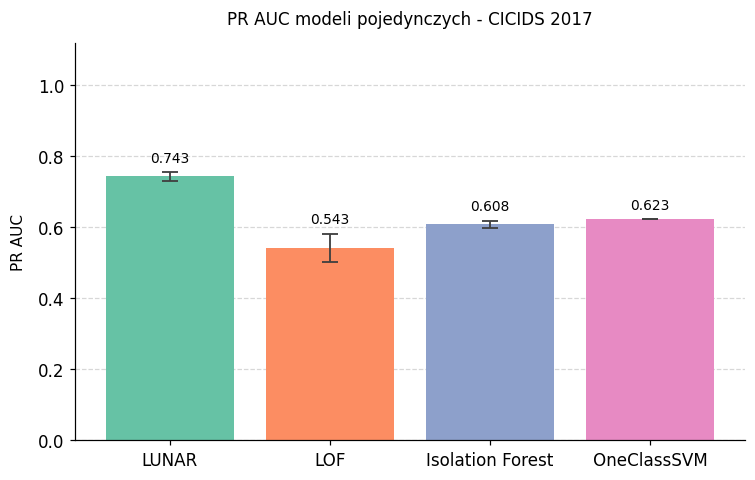

Zapisano: 001_solo_unsw_pr_auc.pdf


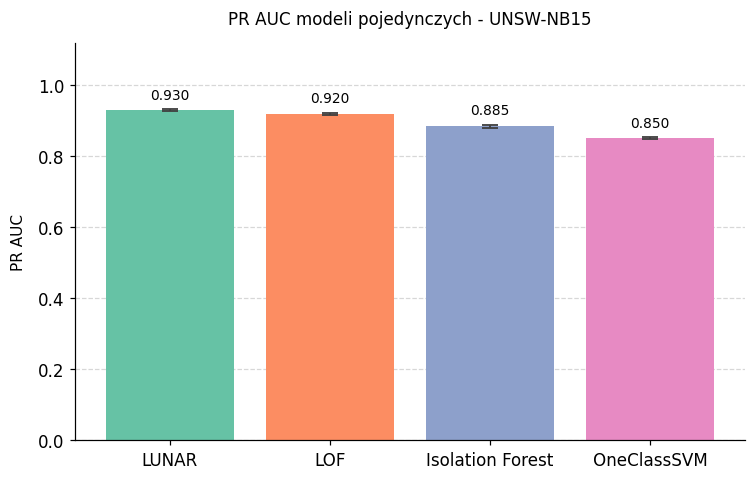

In [87]:
# solo_cicids_pr_auc.pdf / solo_unsw_pr_auc.pdf (fig:solo_cicids_pr_auc, fig:solo_unsw_pr_auc)
for dset in DATASETS:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    means, stds = [], []
    for m in SOLO_MODELS:
        a = agg(df_std_clean, (df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset))
        means.append(a.get("AUC_PR_mean", np.nan))
        stds.append(a.get("AUC_PR_std", np.nan))
    
    labels = [SOLO_LABELS[m] for m in SOLO_MODELS]
    
    rects = ax.bar(
        labels, 
        means, 
        yerr=stds, 
        capsize=5, 
        color=COLORS[:len(SOLO_MODELS)], 
        ecolor="#404040", 
        error_kw={"elinewidth": 1.2, "capthick": 1.2}
    )
    
    for rect, mean, std in zip(rects, means, stds):
        if not np.isnan(mean):
            offset = (std if not np.isnan(std) else 0) + 0.02
            ax.text(
                rect.get_x() + rect.get_width() / 2.0, 
                mean + offset, 
                f"{mean:.3f}", 
                ha="center", 
                va="bottom", 
                fontsize=9, 
            )

    ax.set_ylabel("PR AUC", fontsize=10, labelpad=8)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"PR AUC modeli pojedynczych - {DATASET_LABELS[dset]}", fontsize=11, pad=12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    fig.tight_layout()
    save_fig(fig, f"001_solo_{'cicids' if dset=='CICIDS' else 'unsw'}_pr_auc")
    plt.show()

Zapisano: 002_solo_cicids_f1.pdf


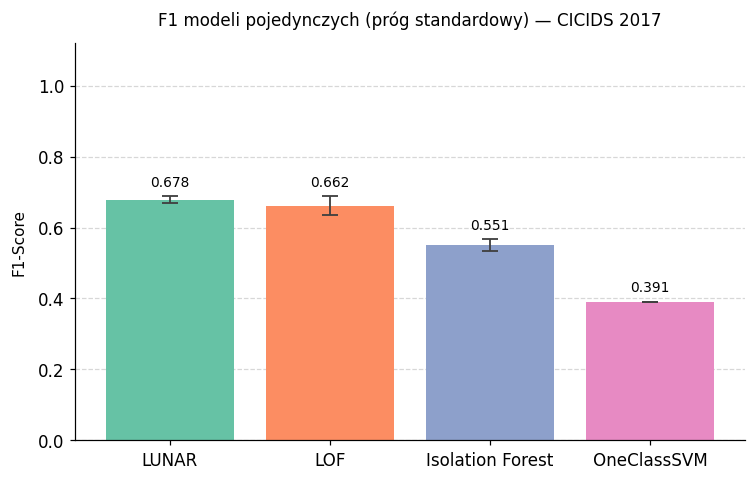

Zapisano: 002_solo_unsw_f1.pdf


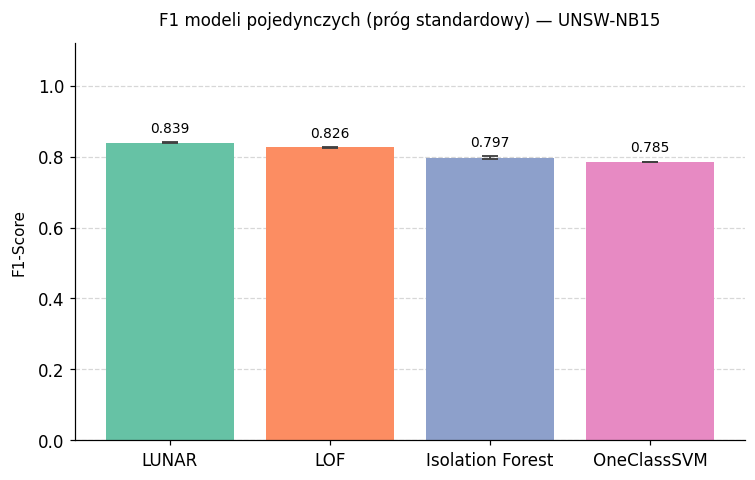

In [88]:
# solo_cicids_f1.pdf / solo_unsw_f1.pdf

for dset in DATASETS:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    means, stds = [], []
    for m in SOLO_MODELS:
        a = agg(df_std_clean, (df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset))
        means.append(a.get("F1_mean", np.nan))
        stds.append(a.get("F1_std", np.nan))

    labels = [SOLO_LABELS[m] for m in SOLO_MODELS]

    bars = ax.bar(
        labels, 
        means, 
        yerr=stds, 
        capsize=5,
        color=[COLORS[i % len(COLORS)] for i in range(len(SOLO_MODELS))],
        ecolor="#404040", 
        error_kw={"elinewidth": 1.2, "capthick": 1.2}
    )

    for bar, mean, std in zip(bars, means, stds):
        if not np.isnan(mean):
            offset = (std if not np.isnan(std) else 0) + 0.02
            ax.text(
                bar.get_x() + bar.get_width() / 2.0, 
                mean + offset, 
                f"{mean:.3f}", 
                ha="center", 
                va="bottom", 
                fontsize=9, 
            )

    ax.set_ylabel("F1-Score", fontsize=10, labelpad=8)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"F1 modeli pojedynczych (próg standardowy) — {DATASET_LABELS[dset]}", 
                 fontsize=11, pad=12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    fig.tight_layout()
    save_fig(fig, f"002_solo_{'cicids' if dset == 'CICIDS' else 'unsw'}_f1")
    plt.show()

Zapisano: 003_solo_cicids_confusion_matrices.pdf


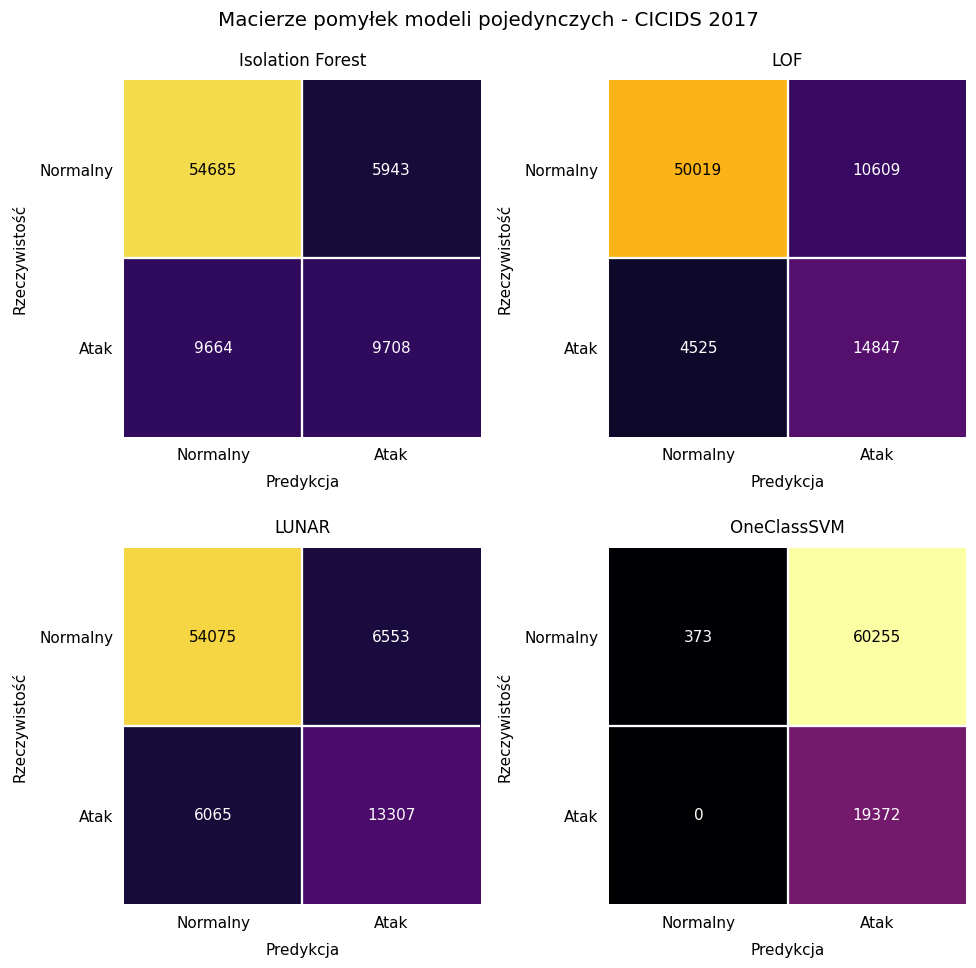

Zapisano: 003_solo_unsw_confusion_matrices.pdf


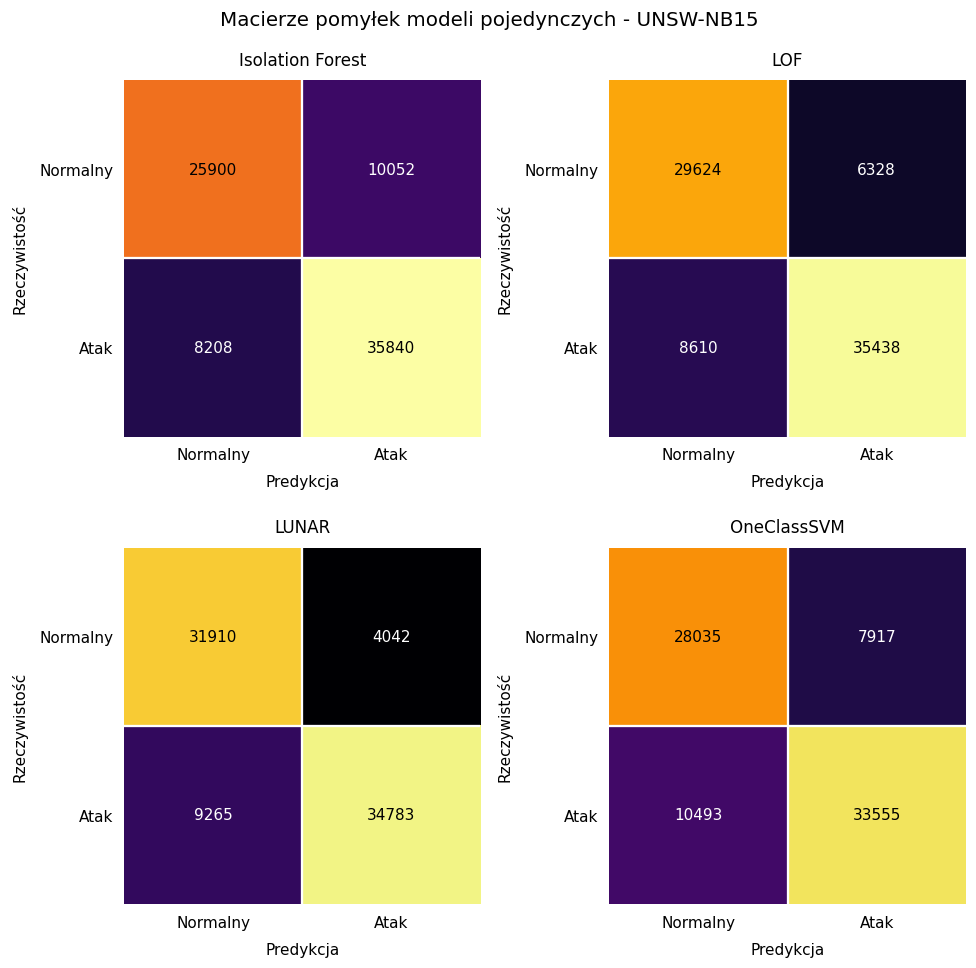

In [89]:
# confusion matrix heatmaps

MODEL_ORDER = ["IsolationForest", "LOF", "LUNAR", "OneClassSVM"]
CM_LABELS = ["Normalny", "Atak"]


def plot_confusion_heatmap(ax, cm, title, vmin, vmax, cmap="inferno"):
    im = ax.imshow(cm, cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.hlines(0.5, -0.5, 1.5, colors="white", linewidth=1.5)
    ax.vlines(0.5, -0.5, 1.5, colors="white", linewidth=1.5)
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    ax.tick_params(which="both", bottom=False, left=False, top=False, right=False)

    norm_vals = (cm - vmin) / (vmax - vmin) if vmax > vmin else cm
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            color = "white" if norm_vals[i, j] < 0.55 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks([0, 1]); ax.set_xticklabels(CM_LABELS, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CM_LABELS, fontsize=10)
    
    ax.set_xlabel("Predykcja", fontsize=10, labelpad=8)
    ax.set_ylabel("Rzeczywistość", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=11, pad=10)
    
    for spine in ax.spines.values():
        spine.set_visible(False)


for dset in DATASETS:
    cms = {}
    for m in MODEL_ORDER:
        sub = df_std_clean[(df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset)]
        if not sub.empty:
            tn = sub["ConfusionMatrix_TN"].mean()
            fp = sub["ConfusionMatrix_FP"].mean()
            fn = sub["ConfusionMatrix_FN"].mean()
            tp = sub["ConfusionMatrix_TP"].mean()
            cms[m] = np.array([[tn, fp], [fn, tp]])
    
    if cms:
        global_vmin = min(cm.min() for cm in cms.values())
        global_vmax = max(cm.max() for cm in cms.values())
    else:
        global_vmin, global_vmax = 0, 1

    fig, axes = plt.subplots(2, 2, figsize=(9, 9))
    for ax, m in zip(axes.flat, MODEL_ORDER):
        if m not in cms:
            ax.axis("off")
            ax.set_title(f"{SOLO_LABELS[m]} -- brak danych")
            continue
        
        plot_confusion_heatmap(
            ax, 
            cms[m], 
            SOLO_LABELS[m], 
            vmin=global_vmin, 
            vmax=global_vmax, 
            cmap="inferno"
        )

    fig.suptitle(f"Macierze pomyłek modeli pojedynczych - {DATASET_LABELS[dset]}",
                 fontsize=13, y=0.98)
    fig.tight_layout()
    save_fig(fig, f"003_solo_{'cicids' if dset == 'CICIDS' else 'unsw'}_confusion_matrices")
    plt.show()

Zapisano: 004_solo_false_positives_false_negatives.pdf


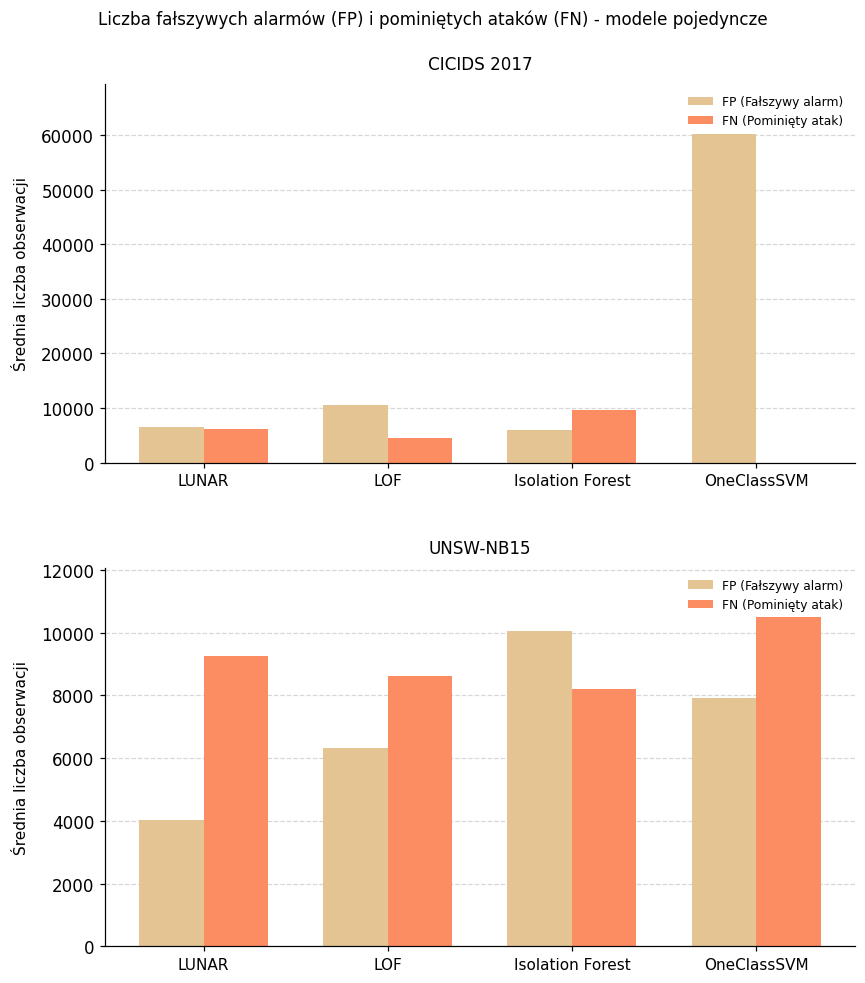

In [90]:
# solo_false_positives_false_negatives.pdf (fig:solo_fp_fn)
fig, axes = plt.subplots(2, 1, figsize=(8, 9))
width = 0.35
x = np.arange(len(SOLO_MODELS))

for ax, dset in zip(axes, DATASETS):
    fps, fns = [], []
    for m in SOLO_MODELS:
        sub = df_std_clean[(df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset)]
        fps.append(sub["ConfusionMatrix_FP"].mean() if not sub.empty else 0)
        fns.append(sub["ConfusionMatrix_FN"].mean() if not sub.empty else 0)
    
    rects1 = ax.bar(x - width/2, fps, width, label="FP (Fałszywy alarm)", color=COLORS[6])
    rects2 = ax.bar(x + width/2, fns, width, label="FN (Pominięty atak)", color=COLORS[1])
    
    ax.set_xticks(x)
    ax.set_xticklabels([SOLO_LABELS[m] for m in SOLO_MODELS], rotation=0, fontsize=10)
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylabel("Średnia liczba obserwacji", fontsize=10, labelpad=8)
    
    max_val = max(max(fps, default=0), max(fns, default=0))
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=8)

fig.suptitle("Liczba fałszywych alarmów (FP) i pominiętych ataków (FN) - modele pojedyncze", 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "004_solo_false_positives_false_negatives")
plt.show()

Zapisano: 005_solo_lunar_threshold_tradeoff.pdf


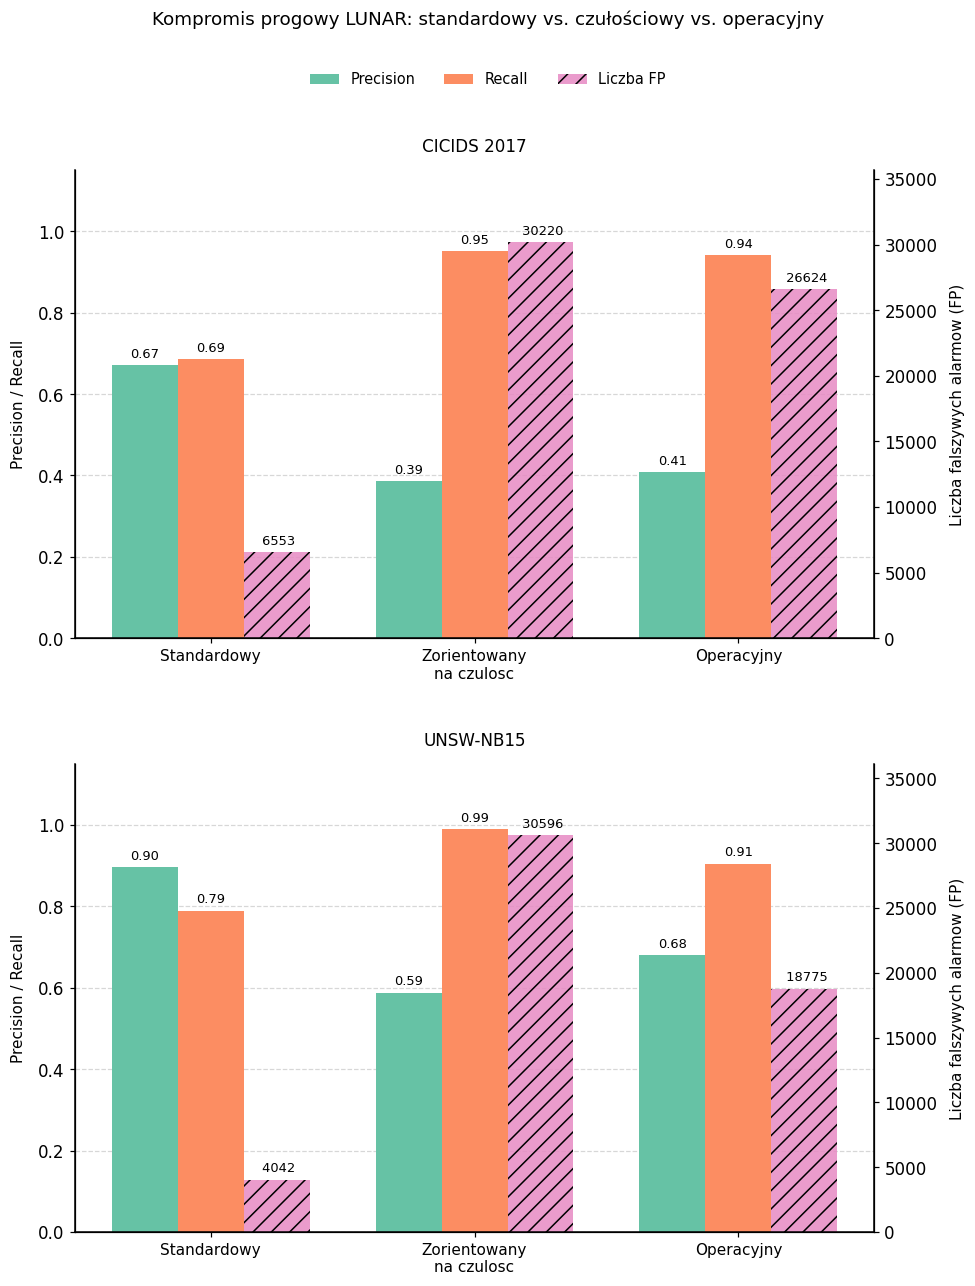

In [91]:
# solo_lunar_threshold_tradeoff.pdf (fig:solo_lunar_threshold_tradeoff)

fig, axes = plt.subplots(2, 1, figsize=(9, 11))
variants = ["standard", "recall_oriented", "operational"]
variant_labels = ["Standardowy", "Zorientowany\nna czulosc", "Operacyjny"]
width = 0.25

for ax, dset in zip(axes, DATASETS):
    prec, rec, fps = [], [], []
    for v in variants:
        sub = df[(df.model_type == "LUNAR") & (df.dataset_name == dset) & (df.threshold_variant == v)]
        prec.append(sub["Precision"].mean())
        rec.append(sub["Recall"].mean())
        fps.append(sub["ConfusionMatrix_FP"].mean() if "ConfusionMatrix_FP" in sub.columns else np.nan)

    x = np.arange(len(variants))
    ax2 = ax.twinx()

    r1 = ax.bar(x - width, prec, width=width, label="Precision", color=COLORS[0])
    r2 = ax.bar(x, rec, width=width, label="Recall", color=COLORS[1])
    r3 = ax2.bar(x + width, fps, width=width, label="Liczba FP", color=COLORS[3], hatch="//", alpha=0.85)

    ax.bar_label(r1, fmt="{:.2f}", padding=3, fontsize=8.5)
    ax.bar_label(r2, fmt="{:.2f}", padding=3, fontsize=8.5)
    ax2.bar_label(r3, fmt="{: .0f}", padding=3, fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(variant_labels, fontsize=10)
    ax.set_ylim(0, 1.15)

    valid_fps = [v for v in fps if not np.isnan(v)]
    max_fp = max(valid_fps) if valid_fps else 1
    ax2.set_ylim(0, max_fp * 1.18)

    ax.set_ylabel("Precision / Recall", fontsize=10, labelpad=8)
    ax2.set_ylabel("Liczba falszywych alarmow (FP)", fontsize=10, labelpad=8)
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=12)

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax2.spines["right"].set_linewidth(0.8)

    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9.5
)

fig.suptitle("Kompromis progowy LUNAR: standardowy vs. czułościowy vs. operacyjny",
             fontsize=12, y=1.06)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "005_solo_lunar_threshold_tradeoff")
plt.show()

Zapisano: 006_solo_runtime.pdf


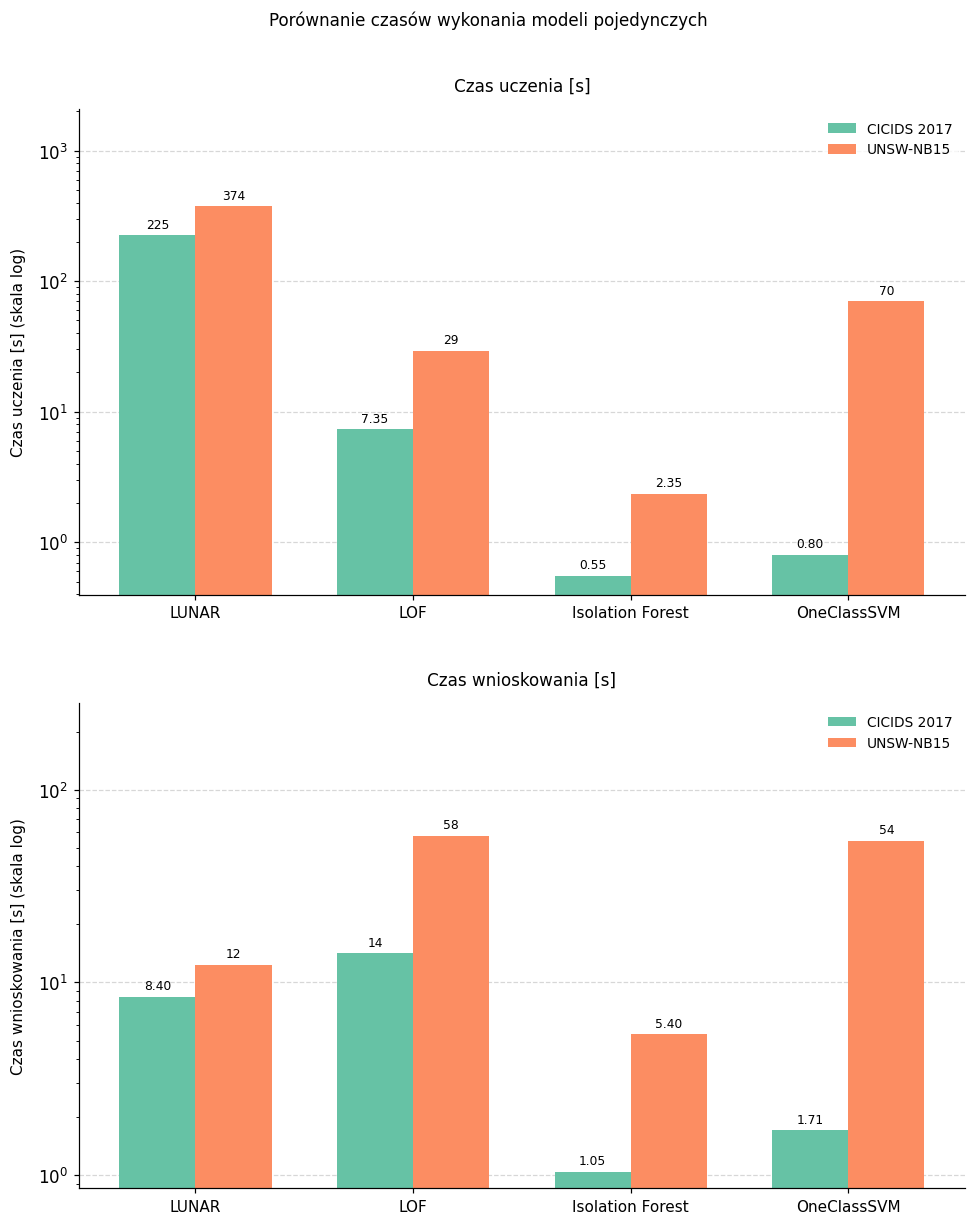

In [92]:
# solo_runtime.pdf (fig:solo_runtime)
fig, axes = plt.subplots(2, 1, figsize=(9, 11))
width = 0.35
xpos = np.arange(len(SOLO_MODELS))

for ax, metric, title in zip(axes, ["runtime_train", "runtime_inference"],
                               ["Czas uczenia [s]", "Czas wnioskowania [s]"]):
    for j, dset in enumerate(DATASETS):
        means = [agg(df_std_clean, (df_std_clean.model_type == m) & (df_std_clean.dataset_name == dset))
                 .get(f"{metric}_mean", np.nan) for m in SOLO_MODELS]
        
        rects = ax.bar(xpos + (j - 0.5) * width, means, width, label=DATASET_LABELS[dset],
                       color=COLORS[j])
        
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height) and height > 0:
                fmt_str = f"{height:.2f}" if height < 10 else f"{height:.0f}"
                ax.annotate(
                    fmt_str,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8
                )

    ax.set_yscale("log")
    
    ylim_max = ax.get_ylim()[1]
    ax.set_ylim(top=ylim_max * 4)

    ax.set_xticks(xpos)
    ax.set_xticklabels([SOLO_LABELS[m] for m in SOLO_MODELS], rotation=0, fontsize=10)
    ax.set_ylabel(f"{title} (skala log)", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=11, pad=12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, which="major", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=9)

fig.suptitle("Porównanie czasów wykonania modeli pojedynczych", fontsize=11, y=1.01)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "006_solo_runtime")
plt.show()

## Sekcja 2: Stabilnosc homogenicznego zespolu LUNAR

Wplyw liczby epok, porownanie strategii self-ensemble (bagging/boosting/stacking/voting), koszt, FP/FN.

In [93]:
# Tabela porównawcza LUNAR i zespołów (tab:lunar_self_ensemble)


VARIANT_SPECS = [
    ("LUNAR", "LUNAR", None),
    ("Bagging", "LUNAR_Self_Ensemble", "bagging"),
    ("Boosting", "LUNAR_Self_Ensemble", "boosting"),
    ("Stacking", "LUNAR_Self_Ensemble", "stacking"),
    ("Voting", "LUNAR_Self_Ensemble", "voting"),
]
METRICS = ["AUC_ROC", "AUC_PR", "F1", "runtime_train"]


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def get_mask(df_in, dset, mtype, fstrat):
    mask = (df_in.dataset_name == dset) & (df_in.model_type == mtype)
    if fstrat is not None:
        mask &= (df_in.fusion_strategy == fstrat)
    return mask


def build_lunar_ensemble_table_latex(df_in, label, caption):
    lines = [
        r"\begin{table}[H]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{llrrrr}",
        r"\hline",
        r"Zbiór & Wariant & ROC AUC & PR AUC & $F_1$ & Czas uczenia [s] \\",
        r"\hline",
    ]

    for d_idx, dset in enumerate(DATASETS):
        dset_label = DATASET_LABELS[dset]
        for label_v, mtype, fstrat in VARIANT_SPECS:
            mask = get_mask(df_in, dset, mtype, fstrat)
            a = agg(df_in, mask, metrics=METRICS)

            cells = [dset_label, label_v]
            for m in METRICS:
                mean = a.get(f"{m}_mean", np.nan)
                std = a.get(f"{m}_std", np.nan)
                nd = 2 if "runtime" in m else 3  # czas: 2 miejsca po przecinku, reszta: 3

                if pd.isna(mean):
                    cells.append("--")
                elif pd.isna(std) or std == 0:
                    cells.append(f"${latex_num(mean, nd)}$")
                else:
                    cells.append(f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$")

            lines.append(" & ".join(cells) + r" \\")

        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")

    lines += [
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
        "",
        r"Źródło: opracowanie własne."
    ]
    return "\n".join(lines)


caption = "Porównanie pojedynczego LUNAR i~zespołów homogenicznych przy~progu standardowym"
label = "tab:lunar_self_ensemble"

tex = build_lunar_ensemble_table_latex(df_std_clean, label, caption)
print(tex)

fname = "table_lunar_self_ensemble"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
for dset in DATASETS:
    for label_v, mtype, fstrat in VARIANT_SPECS:
        mask = get_mask(df_std_clean, dset, mtype, fstrat)
        a = agg(df_std_clean, mask, metrics=METRICS)

        row = {"Zbiór": DATASET_LABELS[dset], "Wariant": label_v}
        for m in METRICS:
            mean = a.get(f"{m}_mean", np.nan)
            std = a.get(f"{m}_std", np.nan)
            if pd.isna(mean):
                row[m] = "--"
            else:
                row[m] = f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}"
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~zespołów homogenicznych przy~progu standardowym}
\label{tab:lunar_self_ensemble}
\begin{tabular}{llrrrr}
\hline
Zbiór & Wariant & ROC AUC & PR AUC & $F_1$ & Czas uczenia [s] \\
\hline
CICIDS 2017 & LUNAR & $0{,}869 \pm 0{,}004$ & $0{,}743 \pm 0{,}013$ & $0{,}678 \pm 0{,}010$ & $224{,}77 \pm 80{,}43$ \\
CICIDS 2017 & Bagging & $0{,}865 \pm 0{,}002$ & $0{,}735 \pm 0{,}001$ & $0{,}668 \pm 0{,}005$ & $1182{,}46 \pm 397{,}01$ \\
CICIDS 2017 & Boosting & $0{,}867 \pm 0{,}000$ & $0{,}736 \pm 0{,}002$ & $0{,}669 \pm 0{,}003$ & $1188{,}31 \pm 409{,}43$ \\
CICIDS 2017 & Stacking & $0{,}782 \pm 0{,}145$ & $0{,}684 \pm 0{,}087$ & $0{,}649 \pm 0{,}041$ & $1193{,}97 \pm 375{,}17$ \\
CICIDS 2017 & Voting & $0{,}794 \pm 0{,}004$ & $0{,}551 \pm 0{,}006$ & $0{,}682 \pm 0{,}002$ & $1247{,}42 \pm 368{,}04$ \\
\hline
UNSW-NB15 & LUNAR & $0{,}889 \pm 0{,}005$ & $0{,}930 \pm 0{,}002$ & $0{,}839 \pm 0{,}002$ & $373{,}52 \pm 61{,}87$ \\
UNSW-

,Zbiór,Wariant,AUC_ROC,AUC_PR,F1,runtime_train
0,CICIDS 2017,LUNAR,0.869 +/- 0.004,0.743 +/- 0.013,0.678 +/- 0.010,224.768 +/- 80.428
1,CICIDS 2017,Bagging,0.865 +/- 0.002,0.735 +/- 0.001,0.668 +/- 0.005,1182.462 +/- 397.006
2,CICIDS 2017,Boosting,0.867 +/- 0.000,0.736 +/- 0.002,0.669 +/- 0.003,1188.309 +/- 409.432
3,CICIDS 2017,Stacking,0.782 +/- 0.145,0.684 +/- 0.087,0.649 +/- 0.041,1193.973 +/- 375.173
4,CICIDS 2017,Voting,0.794 +/- 0.004,0.551 +/- 0.006,0.682 +/- 0.002,1247.424 +/- 368.040
5,UNSW-NB15,LUNAR,0.889 +/- 0.005,0.930 +/- 0.002,0.839 +/- 0.002,373.523 +/- 61.874
6,UNSW-NB15,Bagging,0.888 +/- 0.005,0.930 +/- 0.002,0.840 +/- 0.006,1878.448 +/- 308.017
7,UNSW-NB15,Boosting,0.888 +/- 0.004,0.928 +/- 0.003,0.840 +/- 0.006,1867.916 +/- 295.802
8,UNSW-NB15,Stacking,0.892 +/- 0.003,0.932 +/- 0.002,0.839 +/- 0.006,1868.921 +/- 299.742
9,UNSW-NB15,Voting,0.849 +/- 0.005,0.843 +/- 0.009,0.838 +/- 0.003,1868.709 +/- 298.064


In [94]:
VARIANT_SPECS = [
    ("LUNAR", "LUNAR", None),
    ("Bagging", "LUNAR_Self_Ensemble", "bagging"),
    ("Boosting", "LUNAR_Self_Ensemble", "boosting"),
    ("Stacking", "LUNAR_Self_Ensemble", "stacking"),
    ("Voting", "LUNAR_Self_Ensemble", "voting"),
]


def get_mask(df_in, dset, mtype, fstrat):
    mask = (df_in.dataset_name == dset) & (df_in.model_type == mtype)
    if fstrat is not None:
        mask &= (df_in.fusion_strategy == fstrat)
    return mask


VARIANT_LABELS_PLOT = [lv for lv, _, _ in VARIANT_SPECS]

Zapisano: 007_lunar_self_ensemble_comparison.pdf


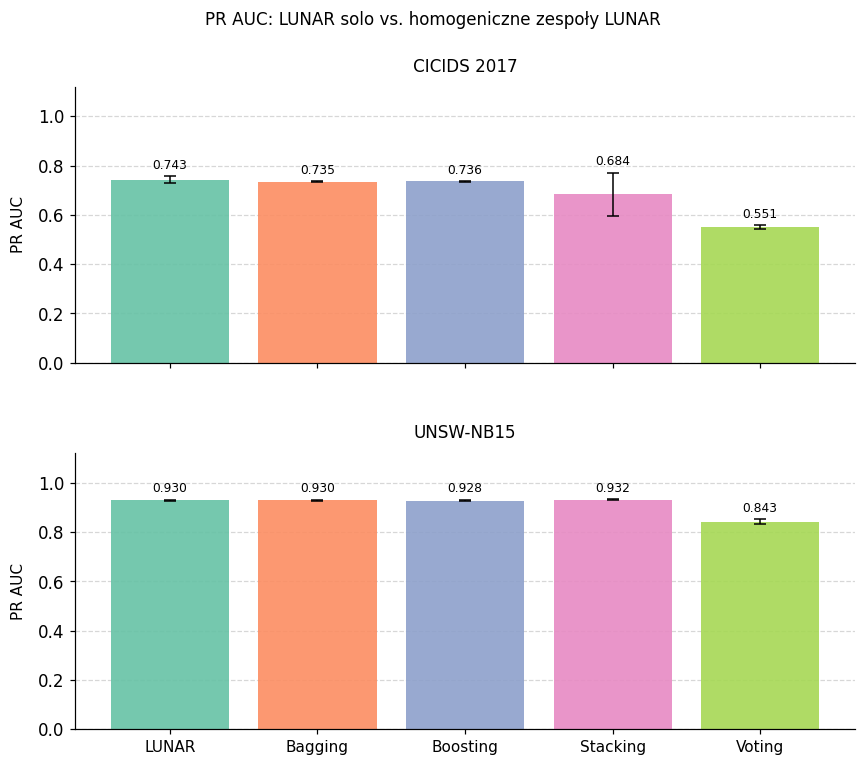

In [95]:
# lunar_self_ensemble_comparison.pdf (fig:lunar_self_ensemble)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

for ax, dset in zip(axes, DATASETS):
    means, stds = [], []
    for label_v, mtype, fstrat in VARIANT_SPECS:
        a = agg(df_std_clean, get_mask(df_std_clean, dset, mtype, fstrat))
        means.append(a.get("AUC_PR_mean", np.nan))
        stds.append(a.get("AUC_PR_std", np.nan))
        
    rects = ax.bar(
        VARIANT_LABELS_PLOT, 
        means, 
        yerr=stds, 
        capsize=4, 
        color=[COLORS[i % len(COLORS)] for i in range(len(VARIANT_SPECS))],
        alpha=0.9,
        error_kw={"ecolor": "black", "linewidth": 1}
    )
    
    ax.bar_label(rects, fmt="{:.3f}", padding=3, fontsize=8)
    
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylabel("PR AUC", fontsize=10, labelpad=8)
    ax.set_ylim(0, 1.12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

# Etykiety osi X widoczne na dolnym wykresie
axes[-1].set_xticks(range(len(VARIANT_LABELS_PLOT)))
axes[-1].set_xticklabels(VARIANT_LABELS_PLOT, rotation=0, fontsize=10)

fig.suptitle("PR AUC: LUNAR solo vs. homogeniczne zespoły LUNAR", 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "007_lunar_self_ensemble_comparison")
plt.show()

Zapisano: 008_lunar_self_ensemble_runtime.pdf


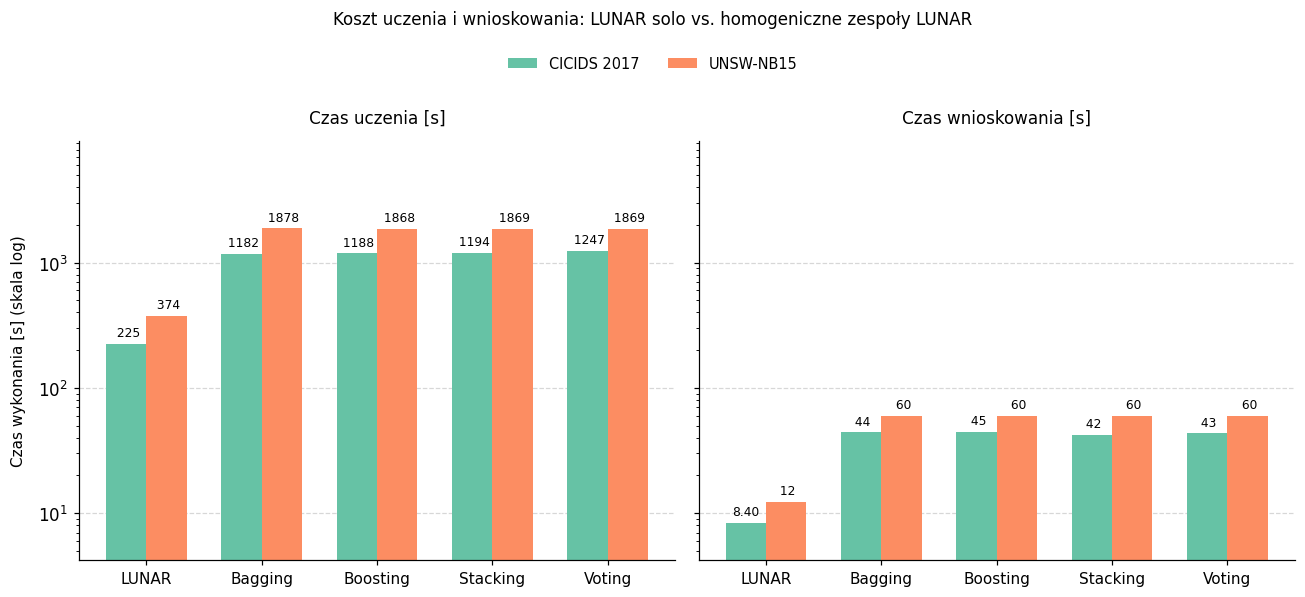

In [133]:
# lunar_self_ensemble_runtime.pdf (fig:lunar_self_runtime)

all_vals = []
for metric in ["runtime_train", "runtime_inference"]:
    for dset in DATASETS:
        for label_v, mtype, fstrat in VARIANT_SPECS:
            a = agg(df_std_clean, get_mask(df_std_clean, dset, mtype, fstrat))
            val = a.get(f"{metric}_mean", np.nan)
            if not pd.isna(val) and val > 0:
                all_vals.append(val)

global_min = min(all_vals) if all_vals else 0.01
global_max = max(all_vals) if all_vals else 100

y_limit_bottom = global_min * 0.5
y_limit_top = global_max * 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
width = 0.35
xpos = np.arange(len(VARIANT_LABELS_PLOT))

for ax, metric, title in zip(axes, ["runtime_train", "runtime_inference"],
                               ["Czas uczenia [s]", "Czas wnioskowania [s]"]):
    for j, dset in enumerate(DATASETS):
        vals = []
        for label_v, mtype, fstrat in VARIANT_SPECS:
            a = agg(df_std_clean, get_mask(df_std_clean, dset, mtype, fstrat))
            vals.append(a.get(f"{metric}_mean", np.nan))
            
        rects = ax.bar(
            xpos + (j - 0.5) * width, 
            vals, 
            width, 
            label=DATASET_LABELS[dset],
            color=COLORS[j]
        )
        
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height) and height > 0:
                fmt_str = f"{height:.2f}" if height < 10 else f"{height: .0f}"
                ax.annotate(
                    fmt_str,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8
                )

    ax.set_yscale("log")
    
    ax.set_ylim(bottom=y_limit_bottom, top=y_limit_top)

    ax.set_xticks(xpos)
    ax.set_xticklabels(VARIANT_LABELS_PLOT, rotation=0, fontsize=10)
    ax.set_title(title, fontsize=11, pad=12)
    
    # Stylizacja osi i siatki
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, which="major", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Czas wykonania [s] (skala log)", fontsize=10, labelpad=8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, 
    loc="upper center", 
    ncol=2, 
    frameon=True, 
    facecolor="white", 
    edgecolor="none",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9.5
)

fig.suptitle("Koszt uczenia i wnioskowania: LUNAR solo vs. homogeniczne zespoły LUNAR", 
             fontsize=11, y=1.08)

fig.tight_layout()
save_fig(fig, "008_lunar_self_ensemble_runtime")
plt.show()

Zapisano: 009_lunar_epochs_pr_auc.pdf


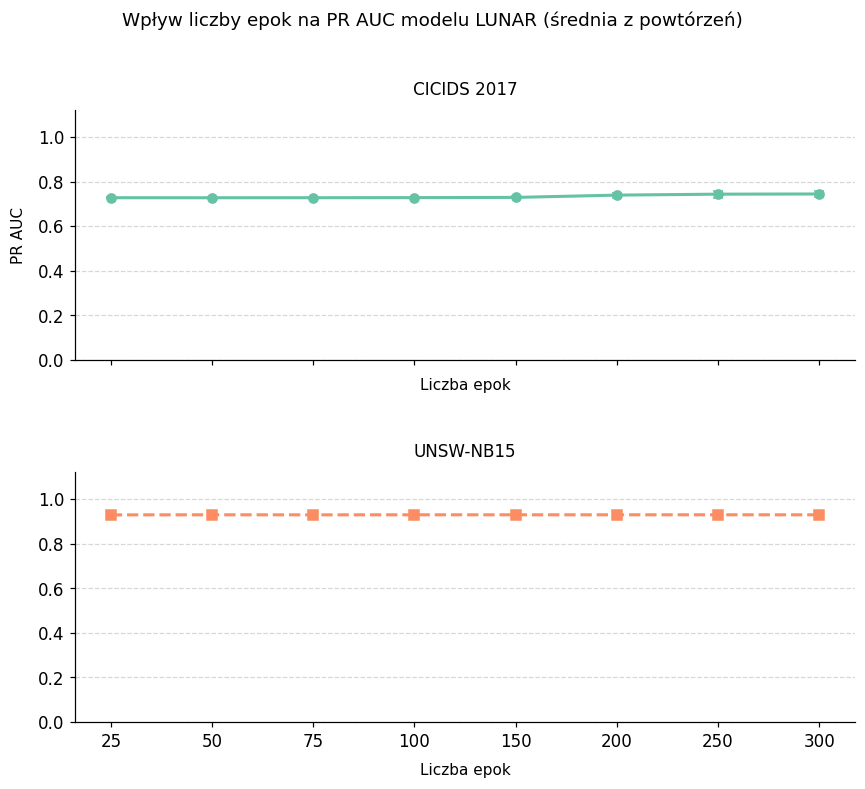

In [97]:
# PR AUC w funkcji liczby epok (fig:lunar_epochs_pr_auc_runtime, gorny panel)

epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())

fig1, axes1 = plt.subplots(2, 1, figsize=(8, 7), sharex=True)


for ax, dset, color, marker, ls in zip(axes1, DATASETS, [COLORS[0], COLORS[1]],
                                        MARKERS[:2], LINESTYLES[:2]):
    sub = epochs_df[epochs_df.dataset_name == dset]
    grouped = sub.groupby(ep_col)["AUC_PR"].agg(["mean", "std"]).reindex(unique_epochs)
    xpos = np.arange(len(unique_epochs))

    ax.errorbar(xpos, grouped["mean"], yerr=grouped["std"], marker=marker, color=color,
                linestyle=ls, linewidth=2, markersize=6, capsize=3)

    ax.set_xticks(xpos)
    ax.set_xticklabels([int(e) for e in unique_epochs])
    ax.set_xlabel("Liczba epok", fontsize=10, labelpad=8)
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylim(0, 1.12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

axes1[0].set_ylabel("PR AUC", fontsize=10, labelpad=8)

fig1.suptitle("Wpływ liczby epok na PR AUC modelu LUNAR (średnia z powtórzeń)",
              fontsize=12, y=1.02)
fig1.tight_layout(h_pad=3.0)
save_fig(fig1, "009_lunar_epochs_pr_auc")
plt.show()

Zapisano: 010_lunar_epochs_runtime.pdf


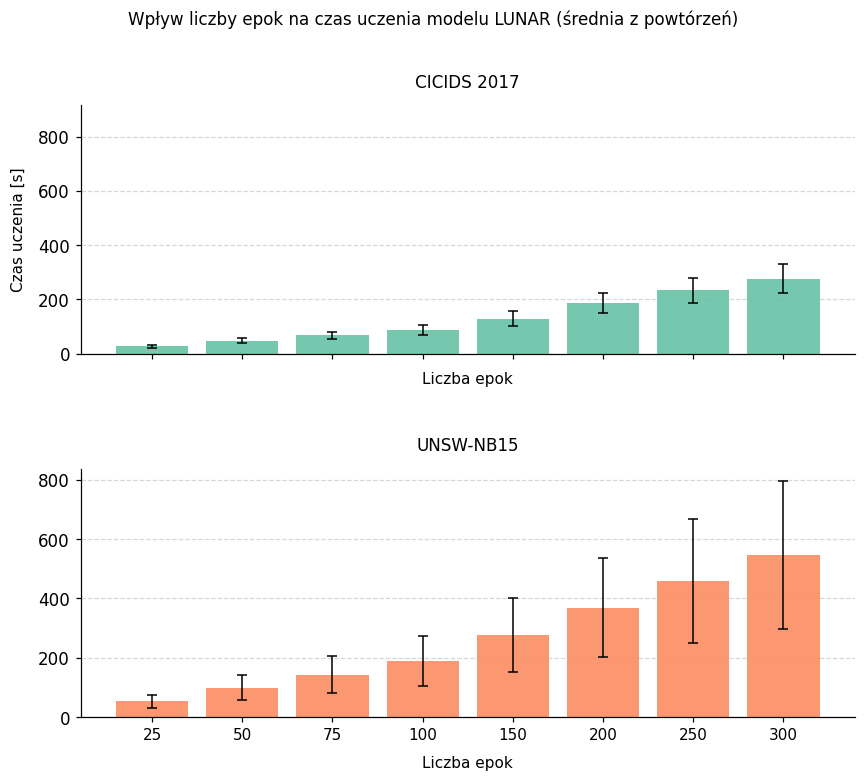

In [98]:
# lunar_epochs_runtime.pdf (fig:lunar_epochs_runtime)

epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())

fig2, axes2 = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

max_y_val = 0

for ax, dset, color in zip(axes2, DATASETS, [COLORS[0], COLORS[1]]):
    sub = epochs_df[epochs_df.dataset_name == dset]
    grouped = sub.groupby(ep_col)["runtime_train"].agg(["mean", "std"]).reindex(unique_epochs)
    xpos = np.arange(len(unique_epochs))

    bars = ax.bar(
        xpos, 
        grouped["mean"], 
        yerr=grouped["std"], 
        capsize=3,
        color=color, 
        alpha=0.9,
        error_kw={"ecolor": "black", "linewidth": 1, "capthick": 1}
    )

    for rect, m, s in zip(bars, grouped["mean"], grouped["std"]):
        if pd.isna(m):
            continue
        
        std_val = 0 if pd.isna(s) else s
        top_of_err = m + std_val
        
        if top_of_err > max_y_val:
            max_y_val = top_of_err
            
        fmt_str = f"{m:,.0f}s" if m >= 60 else f"{m:.1f}s"
        
        # ax.annotate(
        #     fmt_str, 
        #     xy=(rect.get_x() + rect.get_width() / 2, top_of_err), 
        #     xytext=(0, 4),  # 4 punkty odstępu nad wąsem
        #     textcoords="offset points", 
        #     ha="center", 
        #     va="bottom",
        #     fontsize=8
        # )

    ax.set_xticks(xpos)
    ax.set_xticklabels([int(e) for e in unique_epochs], rotation=0, fontsize=10)
    ax.set_xlabel("Liczba epok", fontsize=10, labelpad=8)
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

axes2[0].set_ylim(0, max_y_val * 1.15)
axes2[0].set_ylabel("Czas uczenia [s]", fontsize=10, labelpad=8)

fig2.suptitle("Wpływ liczby epok na czas uczenia modelu LUNAR (średnia z powtórzeń)",
             fontsize=11, y=1.01)

fig2.tight_layout(h_pad=3.0)
save_fig(fig2, "010_lunar_epochs_runtime")
plt.show()

Zapisano: 011_lunar_epochs_threshold_metrics.pdf


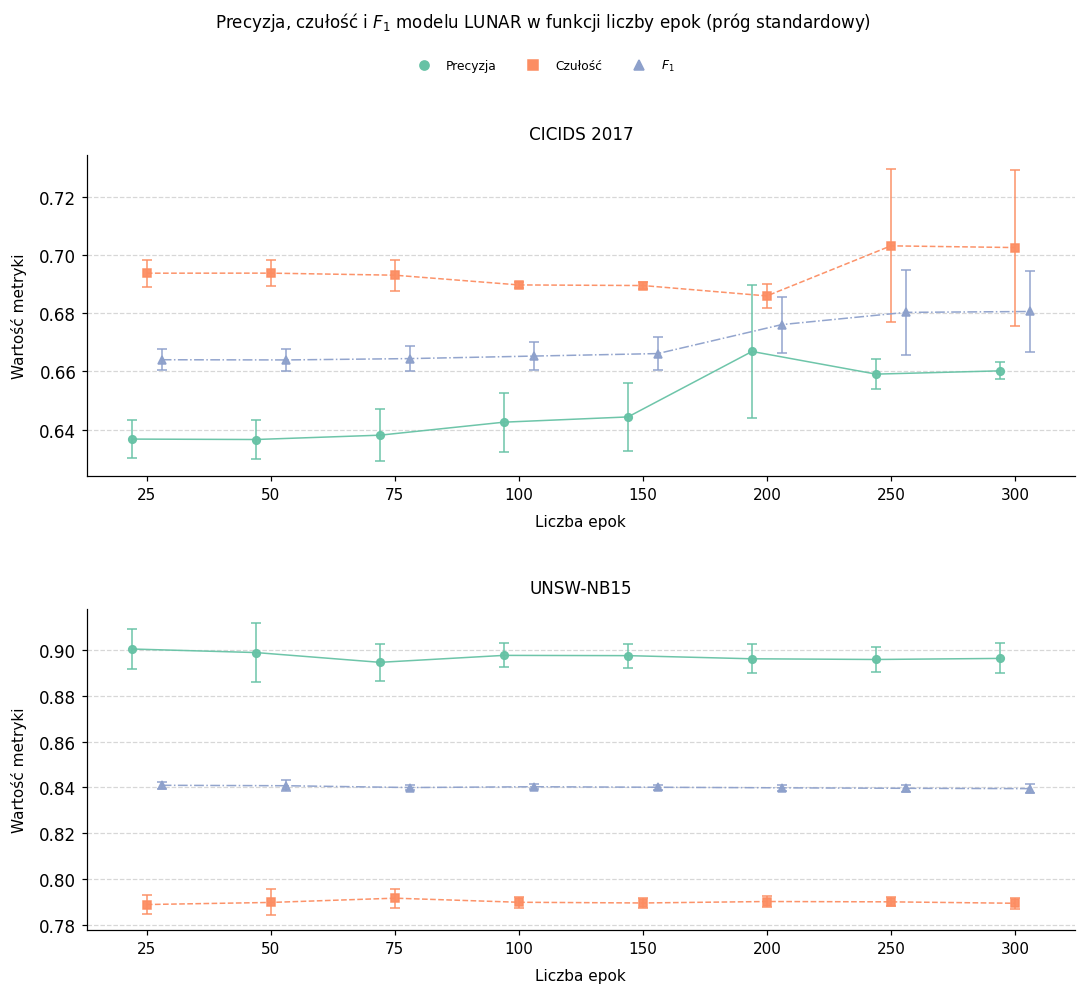

In [99]:
# lunar_epochs_threshold_metrics.pdf (fig:lunar_epochs_threshold_metrics)

epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())
xpos = np.arange(len(unique_epochs))

fig, axes = plt.subplots(2, 1, figsize=(10, 8.5))

metric_offsets = [-0.12, 0.0, 0.12]
metric_labels = {"Precision": "Precyzja", "Recall": "Czułość", "F1": "$F_1$"}

for ax, dset in zip(axes, DATASETS):
    sub = epochs_df[epochs_df.dataset_name == dset]
    
    for j, (metric, mk, ls) in enumerate(zip(["Precision", "Recall", "F1"], MARKERS[:3], LINESTYLES[:3])):
        grouped = sub.groupby(ep_col)[metric].agg(["mean", "std"]).reindex(unique_epochs)
        
        x_shifted = xpos + metric_offsets[j]
        
        ax.errorbar(
            x_shifted, 
            grouped["mean"], 
            yerr=grouped["std"], 
            marker=mk, 
            linestyle=ls,
            color=COLORS[j], 
            label=metric_labels.get(metric, metric), 
            linewidth=1.0, 
            markersize=5, 
            capsize=3,
            capthick=1,
            alpha=0.95
        )

    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylabel("Wartość metryki", fontsize=10, labelpad=8)
    
    ax.set_xticks(xpos)
    ax.set_xticklabels([int(e) for e in unique_epochs], rotation=0, fontsize=10)
    ax.set_xlabel("Liczba epok", fontsize=10, labelpad=8)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()

custom_handles = [
    plt.Line2D([0], [0], marker=h[0].get_marker(), color=h[0].get_color(), 
               linestyle="None", markersize=6) 
    for h in handles
]

fig.legend(
    custom_handles, labels, 
    loc="upper center", 
    ncol=3, 
    frameon=True, 
    facecolor="white", 
    edgecolor="none",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=8
)

fig.suptitle(
    "Precyzja, czułość i $F_1$ modelu LUNAR w funkcji liczby epok (próg standardowy)",
    fontsize=11, y=1.06
)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "011_lunar_epochs_threshold_metrics")
plt.show()

In [100]:
# Tabela lunar_epochs (tab:lunar_epochs)
METRIC_COLS_EPOCHS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1", "runtime_train"]
METRIC_HEADERS_EPOCHS = {
    "AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
    "Recall": "Recall", "F1": "$F_1$", "runtime_train": "Czas uczenia [s]",
}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std) or std == 0:
        return f"${latex_num(mean, nd)}$"
    return f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$"


def build_lunar_epochs_table_latex(df_in, label, caption):
    unique_epochs = sorted(df_in[ep_col].dropna().unique())

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llrrrrrr}", r"\hline",
        "Zbiór & Liczba epok & " + " & ".join(METRIC_HEADERS_EPOCHS[m] for m in METRIC_COLS_EPOCHS) + r" \\",
        r"\hline",
    ]

    for d_idx, dset in enumerate(DATASETS):
        sub_all = df_in[df_in.dataset_name == dset]
        for ep in unique_epochs:
            sub = sub_all[sub_all[ep_col] == ep]
            if sub.empty:
                continue
            cells = [DATASET_LABELS[dset], f"{int(ep)}"]
            for m in METRIC_COLS_EPOCHS:
                nd = 1 if m == "runtime_train" else 3
                mean = sub[m].mean() if m in sub.columns else np.nan
                std = sub[m].std() if m in sub.columns else np.nan
                cells.append(format_cell(mean, std, nd))
            lines.append(" & ".join(cells) + r" \\")
        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")

    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"

caption = ("Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; "
           "średnia $\\pm$ odchylenie standardowe z powtórzeń")
label = "tab:lunar_epochs"

tex = build_lunar_epochs_table_latex(epochs_df, label, caption)
print(tex)

fname = "table_lunar_epochs"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())
for dset in DATASETS:
    sub_all = epochs_df[epochs_df.dataset_name == dset]
    for ep in unique_epochs:
        sub = sub_all[sub_all[ep_col] == ep]
        if sub.empty:
            continue
        row = {"Zbiór": DATASET_LABELS[dset], "Liczba epok": int(ep)}
        for m in METRIC_COLS_EPOCHS:
            mean = sub[m].mean() if m in sub.columns else np.nan
            std = sub[m].std() if m in sub.columns else np.nan
            if pd.isna(mean):
                row[m] = "--"
            else:
                row[m] = f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}"
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; średnia $\pm$ odchylenie standardowe z powtórzeń}
\label{tab:lunar_epochs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrr}
\hline
Zbiór & Liczba epok & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] \\
\hline
CICIDS 2017 & 25 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}002$ & $0{,}637 \pm 0{,}006$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $26{,}2 \pm 5{,}6$ \\
CICIDS 2017 & 50 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}637 \pm 0{,}007$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $46{,}5 \pm 9{,}5$ \\
CICIDS 2017 & 75 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}638 \pm 0{,}009$ & $0{,}693 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $66{,}6 \pm 14{,}6$ \\
CICIDS 2017 & 100 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}643 \pm 0{,}010$ & $0{,}690 \pm 0{,}001$ & $0{,}665 \pm 0{,}005$ & $87{,}1 \pm 18{,}8$ \\
CICIDS 2017 & 150 & $0{,}864

,Zbiór,Liczba epok,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train
0,CICIDS 2017,25,0.863 +/- 0.002,0.728 +/- 0.002,0.637 +/- 0.006,0.694 +/- 0.005,0.664 +/- 0.004,26.209 +/- 5.590
1,CICIDS 2017,50,0.863 +/- 0.002,0.728 +/- 0.003,0.637 +/- 0.007,0.694 +/- 0.005,0.664 +/- 0.004,46.499 +/- 9.503
2,CICIDS 2017,75,0.863 +/- 0.002,0.728 +/- 0.003,0.638 +/- 0.009,0.693 +/- 0.005,0.664 +/- 0.004,66.587 +/- 14.555
3,CICIDS 2017,100,0.863 +/- 0.002,0.728 +/- 0.003,0.643 +/- 0.010,0.690 +/- 0.001,0.665 +/- 0.005,87.098 +/- 18.803
4,CICIDS 2017,150,0.864 +/- 0.002,0.729 +/- 0.004,0.644 +/- 0.012,0.689 +/- 0.001,0.666 +/- 0.006,128.136 +/- 27.985
5,CICIDS 2017,200,0.868 +/- 0.003,0.739 +/- 0.011,0.667 +/- 0.023,0.686 +/- 0.004,0.676 +/- 0.010,187.196 +/- 36.298
6,CICIDS 2017,250,0.870 +/- 0.005,0.744 +/- 0.016,0.659 +/- 0.005,0.703 +/- 0.026,0.680 +/- 0.015,233.095 +/- 46.604
7,CICIDS 2017,300,0.871 +/- 0.006,0.745 +/- 0.015,0.660 +/- 0.003,0.703 +/- 0.027,0.681 +/- 0.014,276.144 +/- 53.336
8,UNSW-NB15,25,0.888 +/- 0.004,0.929 +/- 0.001,0.901 +/- 0.009,0.789 +/- 0.004,0.841 +/- 0.002,52.838 +/- 21.340
9,UNSW-NB15,50,0.888 +/- 0.004,0.929 +/- 0.001,0.899 +/- 0.013,0.790 +/- 0.006,0.841 +/- 0.002,98.810 +/- 41.894


In [101]:
SE_STRATEGIES = ["bagging", "boosting", "stacking", "voting"]
SE_LABELS = {"bagging": "Bagging", "boosting": "Boosting", "stacking": "Stacking", "voting": "Voting"}

COLS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1", "runtime_train", "runtime_inference"]
HEADERS = {
    "AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision", "Recall": "Recall",
    "F1": "$F_1$", "runtime_train": "Czas uczenia [s]", "runtime_inference": "Czas wnioskowania [s]",
}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std) or std == 0:
        return f"${latex_num(mean, nd)}$"
    return f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$"


def build_lunar_self_ensemble_latex(df_in, label, caption):
    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llrrrrrrr}", r"\hline",
        "Zbiór & Wariant & " + " & ".join(HEADERS[c] for c in COLS) + r" \\",
        r"\hline",
    ]

    for d_idx, dset in enumerate(DATASETS):
        a = agg(df_in, (df_in.model_type == "LUNAR") & (df_in.dataset_name == dset))
        cells = [DATASET_LABELS[dset], "LUNAR pojedynczy"]
        for c in COLS:
            nd = 1 if "runtime" in c else 3
            cells.append(format_cell(a.get(f"{c}_mean"), a.get(f"{c}_std"), nd))
        lines.append(" & ".join(cells) + r" \\")

        for strat in SE_STRATEGIES:
            mask = ((df_in.model_type == "LUNAR_Self_Ensemble") &
                    (df_in.fusion_strategy == strat) & (df_in.dataset_name == dset))
            a = agg(df_in, mask)
            cells = [DATASET_LABELS[dset], SE_LABELS[strat]]
            for c in COLS:
                nd = 1 if "runtime" in c else 3
                if strat == "voting" and c in ("AUC_ROC", "AUC_PR"):
                    cells.append("--")  # voting nie generuje ciaglego wyniku anomalii
                else:
                    cells.append(format_cell(a.get(f"{c}_mean"), a.get(f"{c}_std"), nd))
            lines.append(" & ".join(cells) + r" \\")

        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")

    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


caption = "Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR przy~progu standardowym"
label = "tab:lunar_self_ensemble"

tex = build_lunar_self_ensemble_latex(df_std_clean, label, caption)
print(tex)

fname = "table_lunar_self_ensemble"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
for dset in DATASETS:
    a = agg(df_std_clean, (df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset))
    row = {"Zbiór": DATASET_LABELS[dset], "Wariant": "LUNAR pojedynczy"}
    for c in COLS:
        mean, std = a.get(f"{c}_mean"), a.get(f"{c}_std")
        row[c] = "--" if pd.isna(mean) else (f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}")
    preview_rows.append(row)

    for strat in SE_STRATEGIES:
        mask = ((df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                (df_std_clean.fusion_strategy == strat) & (df_std_clean.dataset_name == dset))
        a = agg(df_std_clean, mask)
        row = {"Zbiór": DATASET_LABELS[dset], "Wariant": SE_LABELS[strat]}
        for c in COLS:
            if strat == "voting" and c in ("AUC_ROC", "AUC_PR"):
                row[c] = "--"
                continue
            mean, std = a.get(f"{c}_mean"), a.get(f"{c}_std")
            row[c] = "--" if pd.isna(mean) else (f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}")
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i~homogenicznych zespołów LUNAR przy~progu standardowym}
\label{tab:lunar_self_ensemble}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrrr}
\hline
Zbiór & Wariant & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] & Czas wnioskowania [s] \\
\hline
CICIDS 2017 & LUNAR pojedynczy & $0{,}869 \pm 0{,}004$ & $0{,}743 \pm 0{,}013$ & $0{,}670 \pm 0{,}020$ & $0{,}687 \pm 0{,}001$ & $0{,}678 \pm 0{,}010$ & $224{,}8 \pm 80{,}4$ & $8{,}4 \pm 1{,}3$ \\
CICIDS 2017 & Bagging & $0{,}865 \pm 0{,}002$ & $0{,}735 \pm 0{,}001$ & $0{,}649 \pm 0{,}010$ & $0{,}690 \pm 0{,}001$ & $0{,}668 \pm 0{,}005$ & $1182{,}5 \pm 397{,}0$ & $44{,}0 \pm 9{,}0$ \\
CICIDS 2017 & Boosting & $0{,}867 \pm 0{,}000$ & $0{,}736 \pm 0{,}002$ & $0{,}650 \pm 0{,}007$ & $0{,}688 \pm 0{,}001$ & $0{,}669 \pm 0{,}003$ & $1188{,}3 \pm 409{,}4$ & $44{,}6 \pm 10{,}1$ \\
CICIDS 2017 & Stacking & $0{,}782 \pm 0{,}145$ & $0{,}684 \pm 0{,}087$ & $0{,}727 \p

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR pojedynczy,0.869 +/- 0.004,0.743 +/- 0.013,0.670 +/- 0.020,0.687 +/- 0.001,0.678 +/- 0.010,224.768 +/- 80.428,8.400 +/- 1.295
1,CICIDS 2017,Bagging,0.865 +/- 0.002,0.735 +/- 0.001,0.649 +/- 0.010,0.690 +/- 0.001,0.668 +/- 0.005,1182.462 +/- 397.006,44.041 +/- 9.033
2,CICIDS 2017,Boosting,0.867 +/- 0.000,0.736 +/- 0.002,0.650 +/- 0.007,0.688 +/- 0.001,0.669 +/- 0.003,1188.309 +/- 409.432,44.614 +/- 10.114
3,CICIDS 2017,Stacking,0.782 +/- 0.145,0.684 +/- 0.087,0.727 +/- 0.123,0.613 +/- 0.132,0.649 +/- 0.041,1193.973 +/- 375.173,42.419 +/- 5.795
4,CICIDS 2017,Voting,--,--,0.683 +/- 0.004,0.682 +/- 0.001,0.682 +/- 0.002,1247.424 +/- 368.040,43.410 +/- 5.354
5,UNSW-NB15,LUNAR pojedynczy,0.889 +/- 0.005,0.930 +/- 0.002,0.896 +/- 0.006,0.790 +/- 0.002,0.839 +/- 0.002,373.523 +/- 61.874,12.340 +/- 1.117
6,UNSW-NB15,Bagging,0.888 +/- 0.005,0.930 +/- 0.002,0.906 +/- 0.016,0.783 +/- 0.007,0.840 +/- 0.006,1878.448 +/- 308.017,59.723 +/- 4.472
7,UNSW-NB15,Boosting,0.888 +/- 0.004,0.928 +/- 0.003,0.909 +/- 0.016,0.781 +/- 0.006,0.840 +/- 0.006,1867.916 +/- 295.802,59.762 +/- 4.685
8,UNSW-NB15,Stacking,0.892 +/- 0.003,0.932 +/- 0.002,0.906 +/- 0.014,0.782 +/- 0.008,0.839 +/- 0.006,1868.921 +/- 299.742,59.952 +/- 5.106
9,UNSW-NB15,Voting,--,--,0.895 +/- 0.006,0.788 +/- 0.007,0.838 +/- 0.003,1868.709 +/- 298.064,60.039 +/- 5.050


In [102]:
# Tabela lunar_epochs (tab:lunar_epochs)
METRIC_COLS_EPOCHS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1", "runtime_train"]
METRIC_HEADERS_EPOCHS = {
    "AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
    "Recall": "Recall", "F1": "$F_1$", "runtime_train": "Czas uczenia [s]",
}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std) or std == 0:
        return f"${latex_num(mean, nd)}$"
    return f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$"


def build_lunar_epochs_table_latex(df_in, label, caption):
    unique_epochs = sorted(df_in[ep_col].dropna().unique())

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llrrrrrr}", r"\hline",
        "Zbiór & Liczba epok & " + " & ".join(METRIC_HEADERS_EPOCHS[m] for m in METRIC_COLS_EPOCHS) + r" \\",
        r"\hline",
    ]

    for d_idx, dset in enumerate(DATASETS):
        sub_all = df_in[df_in.dataset_name == dset]
        for ep in unique_epochs:
            sub = sub_all[sub_all[ep_col] == ep]
            if sub.empty:
                continue
            cells = [DATASET_LABELS[dset], f"{int(ep)}"]
            for m in METRIC_COLS_EPOCHS:
                nd = 1 if m == "runtime_train" else 3
                mean = sub[m].mean() if m in sub.columns else np.nan
                std = sub[m].std() if m in sub.columns else np.nan
                cells.append(format_cell(mean, std, nd))
            lines.append(" & ".join(cells) + r" \\")
        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")

    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"

caption = ("Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; "
           "średnia $\\pm$ odchylenie standardowe z powtórzeń")
label = "tab:lunar_epochs"

tex = build_lunar_epochs_table_latex(epochs_df, label, caption)
print(tex)

fname = "table_lunar_epochs"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())
for dset in DATASETS:
    sub_all = epochs_df[epochs_df.dataset_name == dset]
    for ep in unique_epochs:
        sub = sub_all[sub_all[ep_col] == ep]
        if sub.empty:
            continue
        row = {"Zbiór": DATASET_LABELS[dset], "Liczba epok": int(ep)}
        for m in METRIC_COLS_EPOCHS:
            mean = sub[m].mean() if m in sub.columns else np.nan
            std = sub[m].std() if m in sub.columns else np.nan
            if pd.isna(mean):
                row[m] = "--"
            else:
                row[m] = f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}"
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; średnia $\pm$ odchylenie standardowe z powtórzeń}
\label{tab:lunar_epochs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrr}
\hline
Zbiór & Liczba epok & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] \\
\hline
CICIDS 2017 & 25 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}002$ & $0{,}637 \pm 0{,}006$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $26{,}2 \pm 5{,}6$ \\
CICIDS 2017 & 50 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}637 \pm 0{,}007$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $46{,}5 \pm 9{,}5$ \\
CICIDS 2017 & 75 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}638 \pm 0{,}009$ & $0{,}693 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $66{,}6 \pm 14{,}6$ \\
CICIDS 2017 & 100 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}643 \pm 0{,}010$ & $0{,}690 \pm 0{,}001$ & $0{,}665 \pm 0{,}005$ & $87{,}1 \pm 18{,}8$ \\
CICIDS 2017 & 150 & $0{,}864

,Zbiór,Liczba epok,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train
0,CICIDS 2017,25,0.863 +/- 0.002,0.728 +/- 0.002,0.637 +/- 0.006,0.694 +/- 0.005,0.664 +/- 0.004,26.209 +/- 5.590
1,CICIDS 2017,50,0.863 +/- 0.002,0.728 +/- 0.003,0.637 +/- 0.007,0.694 +/- 0.005,0.664 +/- 0.004,46.499 +/- 9.503
2,CICIDS 2017,75,0.863 +/- 0.002,0.728 +/- 0.003,0.638 +/- 0.009,0.693 +/- 0.005,0.664 +/- 0.004,66.587 +/- 14.555
3,CICIDS 2017,100,0.863 +/- 0.002,0.728 +/- 0.003,0.643 +/- 0.010,0.690 +/- 0.001,0.665 +/- 0.005,87.098 +/- 18.803
4,CICIDS 2017,150,0.864 +/- 0.002,0.729 +/- 0.004,0.644 +/- 0.012,0.689 +/- 0.001,0.666 +/- 0.006,128.136 +/- 27.985
5,CICIDS 2017,200,0.868 +/- 0.003,0.739 +/- 0.011,0.667 +/- 0.023,0.686 +/- 0.004,0.676 +/- 0.010,187.196 +/- 36.298
6,CICIDS 2017,250,0.870 +/- 0.005,0.744 +/- 0.016,0.659 +/- 0.005,0.703 +/- 0.026,0.680 +/- 0.015,233.095 +/- 46.604
7,CICIDS 2017,300,0.871 +/- 0.006,0.745 +/- 0.015,0.660 +/- 0.003,0.703 +/- 0.027,0.681 +/- 0.014,276.144 +/- 53.336
8,UNSW-NB15,25,0.888 +/- 0.004,0.929 +/- 0.001,0.901 +/- 0.009,0.789 +/- 0.004,0.841 +/- 0.002,52.838 +/- 21.340
9,UNSW-NB15,50,0.888 +/- 0.004,0.929 +/- 0.001,0.899 +/- 0.013,0.790 +/- 0.006,0.841 +/- 0.002,98.810 +/- 41.894


Zapisano: 012_lunar_self_ensemble_pr_auc.pdf


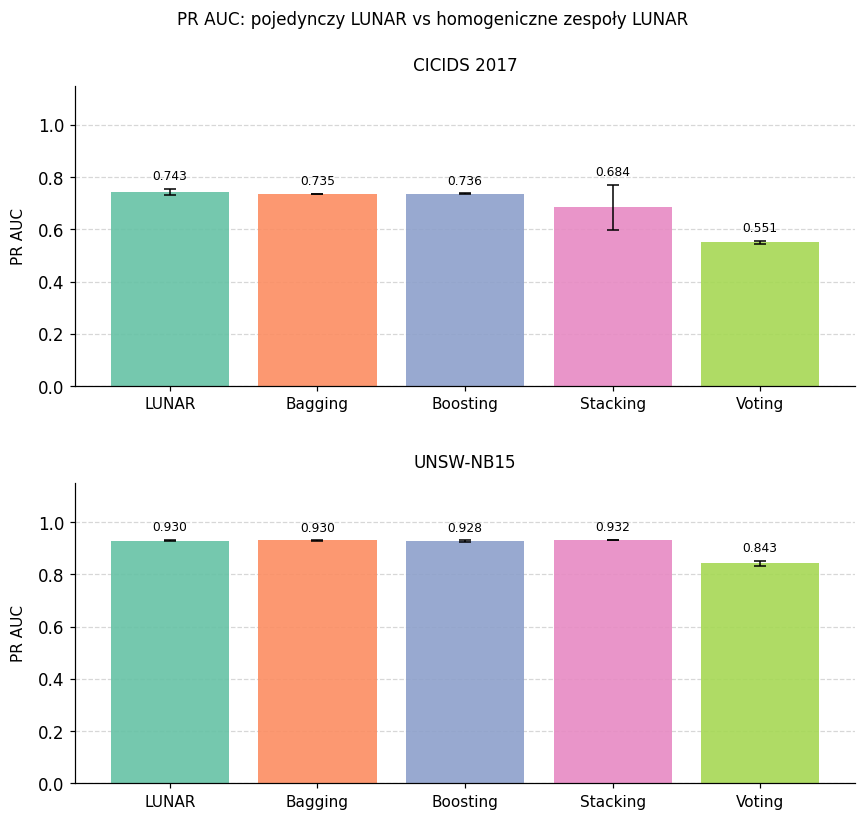

In [103]:
# lunar_self_ensemble_pr_auc.pdf (fig:lunar_self_ensemble_pr_auc)

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))
labels = ["LUNAR"] + [SE_LABELS[s] for s in SE_STRATEGIES]

for ax, dset in zip(axes, DATASETS):
    means, stds = [], []
    
    a = agg(df_std_clean, (df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset))
    means.append(a.get("AUC_PR_mean", np.nan))
    stds.append(a.get("AUC_PR_std", np.nan))
    
    for strat in SE_STRATEGIES:
        mask = ((df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                (df_std_clean.fusion_strategy == strat) & 
                (df_std_clean.dataset_name == dset))
        a = agg(df_std_clean, mask)
        means.append(a.get("AUC_PR_mean", np.nan))
        stds.append(a.get("AUC_PR_std", np.nan))
        
    rects = ax.bar(
        labels, 
        means, 
        yerr=stds, 
        capsize=4, 
        color=COLORS[:len(labels)],
        alpha=0.9,
        error_kw={"ecolor": "black", "linewidth": 1, "capthick": 1}
    )
    
    for rect, m, s in zip(rects, means, stds):
        if not np.isnan(m):
            std_val = 0 if pd.isna(s) else s
            top_pos = m + std_val
            ax.annotate(
                f"{m:.3f}",
                xy=(rect.get_x() + rect.get_width() / 2, top_pos),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center", 
                va="bottom", 
                fontsize=8
            )

    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylabel("PR AUC", fontsize=10, labelpad=8)
    ax.set_ylim(0, 1.15)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle("PR AUC: pojedynczy LUNAR vs homogeniczne zespoły LUNAR", 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=2.5)
save_fig(fig, "012_lunar_self_ensemble_pr_auc")
plt.show()

Zapisano: 013_lunar_self_ensemble_runtime.pdf


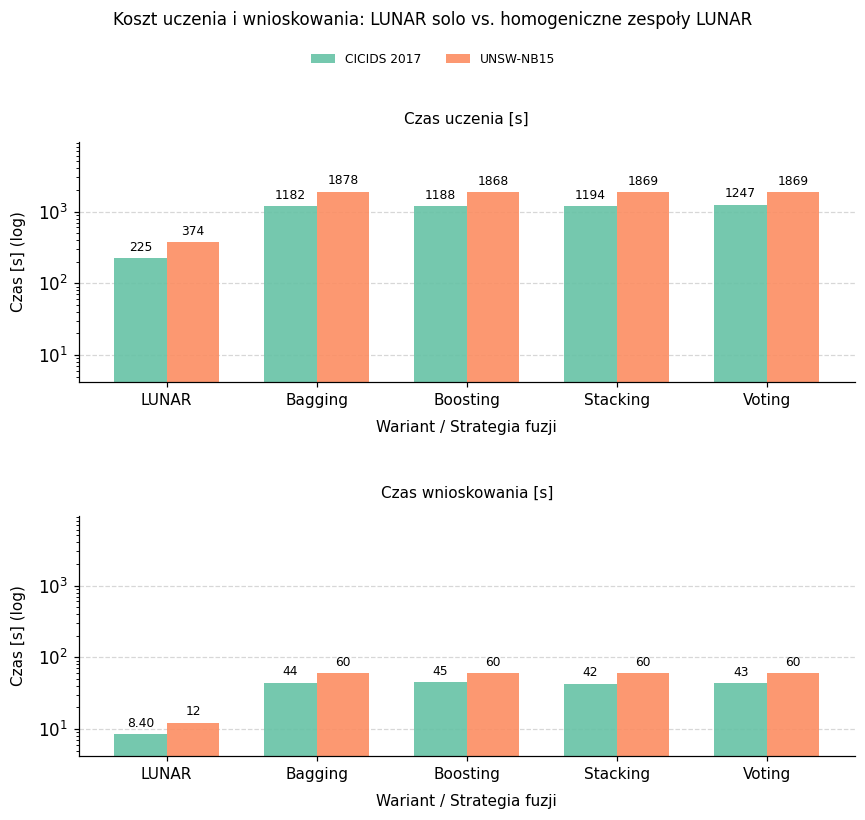

In [132]:
# lunar_self_ensemble_runtime.pdf (fig:lunar_self_ensemble_runtime)

labels = ["LUNAR"] + [SE_LABELS[s] for s in SE_STRATEGIES]

all_vals = []
for metric in ["runtime_train", "runtime_inference"]:
    for dset in DATASETS:
        # Daria dla pojedynczego LUNAR
        a_solo = agg(df_std_clean, (df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset))
        v_solo = a_solo.get(f"{metric}_mean", np.nan)
        if not pd.isna(v_solo) and v_solo > 0:
            all_vals.append(v_solo)
            
        for strat in SE_STRATEGIES:
            mask = ((df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                    (df_std_clean.fusion_strategy == strat) & 
                    (df_std_clean.dataset_name == dset))
            v_strat = agg(df_std_clean, mask).get(f"{metric}_mean", np.nan)
            if not pd.isna(v_strat) and v_strat > 0:
                all_vals.append(v_strat)

global_min = min(all_vals) if all_vals else 0.01
global_max = max(all_vals) if all_vals else 100

y_limit_bottom = global_min * 0.5
y_limit_top = global_max * 5

# Usunięto sharex=True, aby rozdzielić osie X
fig, axes = plt.subplots(2, 1, figsize=(8, 7))
width = 0.35
xpos = np.arange(len(labels))

for ax, metric, title in zip(axes, ["runtime_train", "runtime_inference"],
                               ["Czas uczenia [s]", "Czas wnioskowania [s]"]):
    for j, dset in enumerate(DATASETS):
        vals = []
        # Pobranie danych dla LUNAR
        a_solo = agg(df_std_clean, (df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset))
        vals.append(a_solo.get(f"{metric}_mean", np.nan))
        
        for strat in SE_STRATEGIES:
            mask = ((df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                    (df_std_clean.fusion_strategy == strat) & 
                    (df_std_clean.dataset_name == dset))
            vals.append(agg(df_std_clean, mask).get(f"{metric}_mean", np.nan))
            
        rects = ax.bar(
            xpos + (j - 0.5) * width, 
            vals, 
            width, 
            label=DATASET_LABELS[dset],
            color=COLORS[j],
            alpha=0.9
        )
        
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height) and height > 0:
                fmt_str = f"{height:.2f}" if height < 10 else f"{height:.0f}"
                ax.annotate(
                    fmt_str,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8
                )

    ax.set_yscale("log")
    ax.set_ylim(bottom=y_limit_bottom, top=y_limit_top)

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_xlabel("Wariant / Strategia fuzji", fontsize=10, labelpad=8)
    
    ax.set_title(title, fontsize=10, pad=12)
    ax.set_ylabel("Czas [s] (log)", fontsize=10, labelpad=8)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, which="major", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, 
    loc="upper center", 
    ncol=2, 
    frameon=True, 
    facecolor="white", 
    edgecolor="none",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=8
)

fig.suptitle("Koszt uczenia i wnioskowania: LUNAR solo vs. homogeniczne zespoły LUNAR", 
             fontsize=11, y=1.06)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "013_lunar_self_ensemble_runtime")
plt.show()

Zapisano: 014_lunar_self_ensemble_fp_fn.pdf


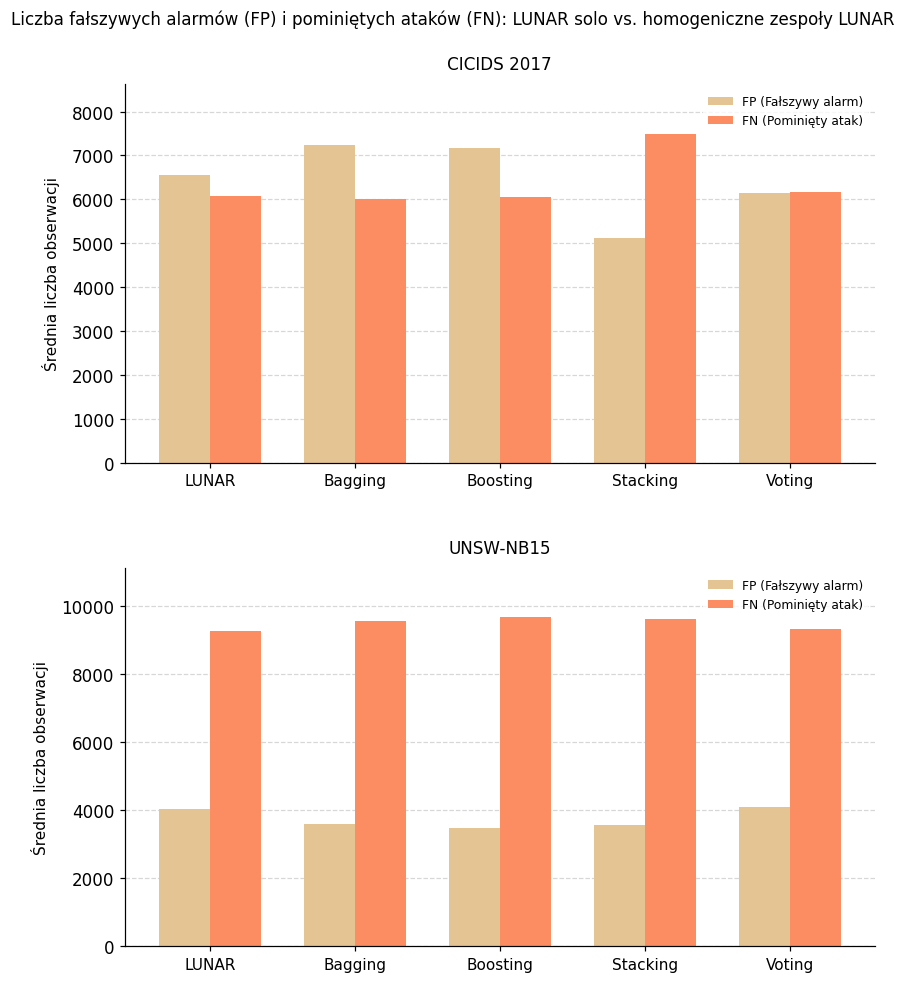

In [136]:
# lunar_self_ensemble_fp_fn.pdf (fig:lunar_self_ensemble_fp_fn)

labels = ["LUNAR"] + [SE_LABELS[s] for s in SE_STRATEGIES]

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
width = 0.35
xpos = np.arange(len(labels))

for ax, dset in zip(axes, DATASETS):
    fps, fns = [], []
    
    # Pobranie danych dla pojedynczego LUNAR
    sub_lunar = df_std_clean[(df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset)]
    fps.append(sub_lunar["ConfusionMatrix_FP"].mean() if not sub_lunar.empty else 0)
    fns.append(sub_lunar["ConfusionMatrix_FN"].mean() if not sub_lunar.empty else 0)
    
    # Pobranie danych dla strategii Self Ensemble
    for strat in SE_STRATEGIES:
        sub_se = df_std_clean[(df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                              (df_std_clean.fusion_strategy == strat) & 
                              (df_std_clean.dataset_name == dset)]
        fps.append(sub_se["ConfusionMatrix_FP"].mean() if not sub_se.empty else 0)
        fns.append(sub_se["ConfusionMatrix_FN"].mean() if not sub_se.empty else 0)
    
    rects1 = ax.bar(xpos - width/2, fps, width, label="FP (Fałszywy alarm)", color=COLORS[6])
    rects2 = ax.bar(xpos + width/2, fns, width, label="FN (Pominięty atak)", color=COLORS[1])
    
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_title(DATASET_LABELS[dset], fontsize=11, pad=10)
    ax.set_ylabel("Średnia liczba obserwacji", fontsize=10, labelpad=8)
    
    max_val = max(max(fps, default=0), max(fns, default=0))
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=8)

fig.suptitle("Liczba fałszywych alarmów (FP) i pominiętych ataków (FN): LUNAR solo vs. homogeniczne zespoły LUNAR", 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=3.0)
save_fig(fig, "014_lunar_self_ensemble_fp_fn")
plt.show()

Zapisano: 015_lunar_self_ensemble_cicids_confusion_matrices.pdf


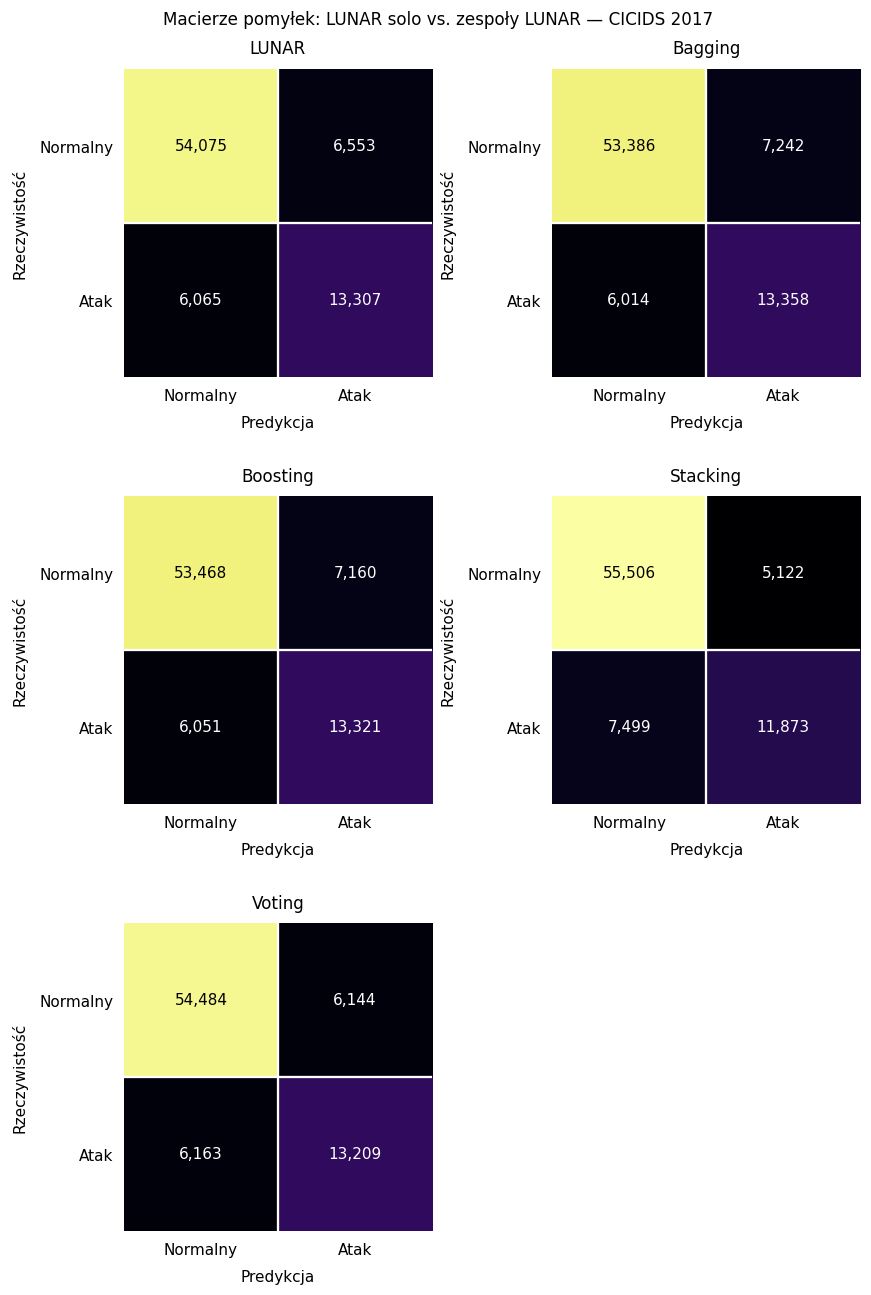

Zapisano: 015_lunar_self_ensemble_unsw_confusion_matrices.pdf


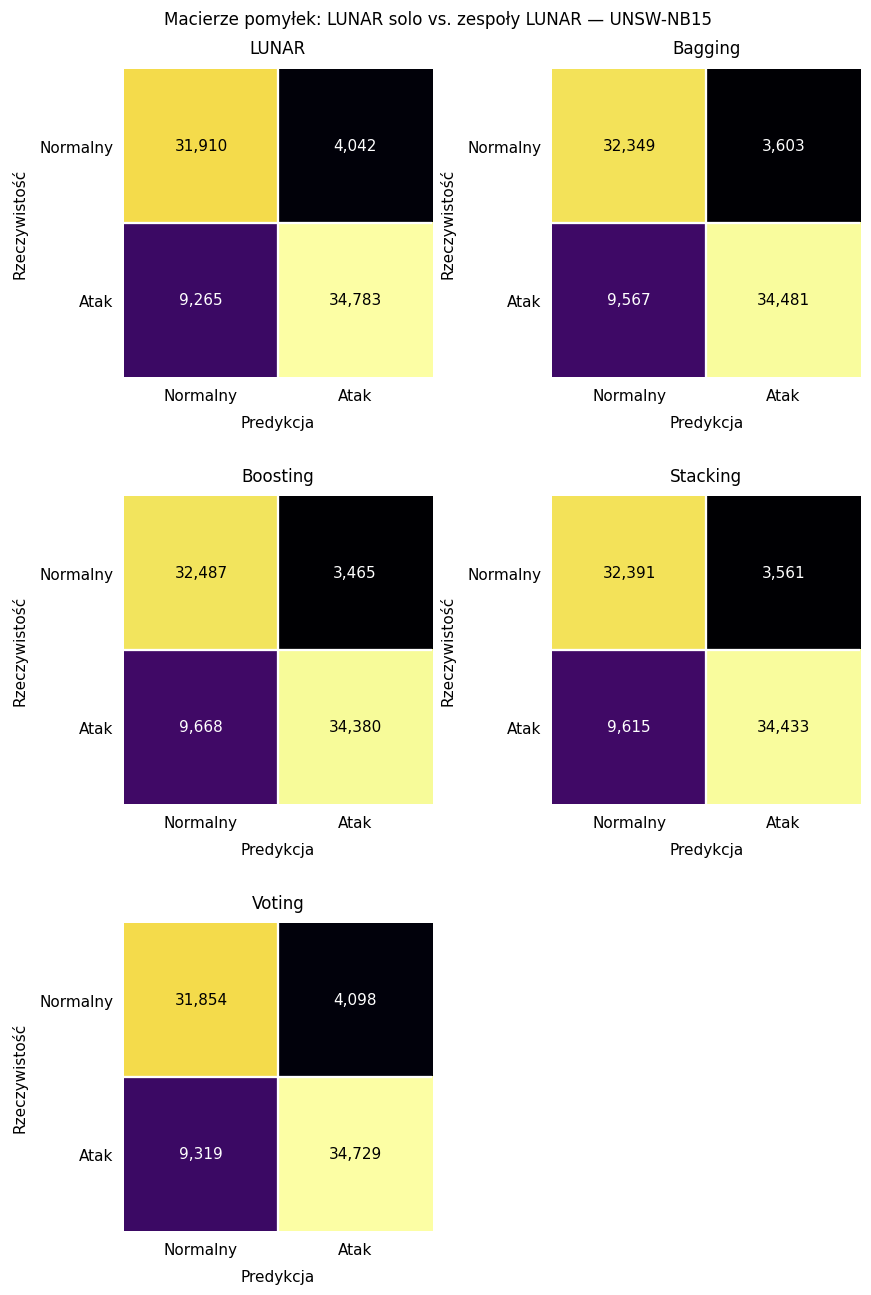

In [145]:
# lunar_self_ensemble_confusion_matrices.pdf (fig:lunar_self_ensemble_confusion_matrices)

CM_LABELS = ["Normalny", "Atak"]

def plot_confusion_heatmap(ax, cm, title, vmin, vmax, cmap="inferno"):
    im = ax.imshow(cm, cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.hlines(0.5, -0.5, 1.5, colors="white", linewidth=1.5)
    ax.vlines(0.5, -0.5, 1.5, colors="white", linewidth=1.5)
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    ax.tick_params(which="both", bottom=False, left=False, top=False, right=False)

    norm_vals = (cm - vmin) / (vmax - vmin) if vmax > vmin else cm
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            color = "white" if norm_vals[i, j] < 0.55 else "black"
            ax.text(j, i, f"{val:,.0f}", ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(CM_LABELS, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(CM_LABELS, fontsize=10)
    
    ax.set_xlabel("Predykcja", fontsize=10, labelpad=8)
    ax.set_ylabel("Rzeczywistość", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=11, pad=10)
    
    for spine in ax.spines.values():
        spine.set_visible(False)


for dset in DATASETS:
    cms = {}
    
    sub_lunar = df_std_clean[(df_std_clean.model_type == "LUNAR") & (df_std_clean.dataset_name == dset)]
    if not sub_lunar.empty:
        tn = sub_lunar["ConfusionMatrix_TN"].mean()
        fp = sub_lunar["ConfusionMatrix_FP"].mean()
        fn = sub_lunar["ConfusionMatrix_FN"].mean()
        tp = sub_lunar["ConfusionMatrix_TP"].mean()
        cms["LUNAR"] = np.array([[tn, fp], [fn, tp]])
        
    for strat in SE_STRATEGIES:
        sub_se = df_std_clean[(df_std_clean.model_type == "LUNAR_Self_Ensemble") &
                              (df_std_clean.fusion_strategy == strat) & 
                              (df_std_clean.dataset_name == dset)]
        if not sub_se.empty:
            tn = sub_se["ConfusionMatrix_TN"].mean()
            fp = sub_se["ConfusionMatrix_FP"].mean()
            fn = sub_se["ConfusionMatrix_FN"].mean()
            tp = sub_se["ConfusionMatrix_TP"].mean()
            cms[SE_LABELS[strat]] = np.array([[tn, fp], [fn, tp]])
            
    if cms:
        global_vmin = min(cm.min() for cm in cms.values())
        global_vmax = max(cm.max() for cm in cms.values())
    else:
        global_vmin, global_vmax = 0, 1

    fig, axes = plt.subplots(3, 2, figsize=(8, 12))
    axes_flat = axes.flat
    
    all_keys = ["LUNAR"] + [SE_LABELS[s] for s in SE_STRATEGIES]
    
    for idx, key in enumerate(all_keys):
        ax = axes_flat[idx]
        if key not in cms:
            ax.axis("off")
            ax.set_title(f"{key} -- brak danych", fontsize=11)
            continue
            
        plot_confusion_heatmap(
            ax, 
            cms[key], 
            key, 
            vmin=global_vmin, 
            vmax=global_vmax, 
            cmap="inferno"
        )
        
    if len(all_keys) < len(axes_flat):
        for unused_ax in axes_flat[len(all_keys):]:
            unused_ax.axis("off")

    fig.suptitle(f"Macierze pomyłek: LUNAR solo vs. zespoły LUNAR — {DATASET_LABELS[dset]}",
                 fontsize=11, y=0.98)
    
    fig.tight_layout(h_pad=2.0)
    save_fig(fig, f"015_lunar_self_ensemble_{'cicids' if dset == 'CICIDS' else 'unsw'}_confusion_matrices")
    plt.show()

## Sekcja 3: Skutecznosc uczenia zespolowego z metodami klasycznymi

Porownanie IF/LOF/OCSVM z zespolem klasycznym (rank mean), macierze pomylek, Recall@FPR=0.01, koszt.

In [ ]:
CLASSICAL_SPECS = [
    ("IsolationForest", None, "Isolation Forest"),
    ("LOF", None, "LOF"),
    ("OneClassSVM", None, "OneClassSVM"),
    ("Ensemble_without_LUNAR", "rank_mean", "Zespół klasyczny"),
]
METRICS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]
METRIC_HEADERS = {"AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
                  "Recall": "Recall", "F1": "$F_1$"}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, is_best, nd=3):
    if pd.isna(mean):
        return "--"
    val = f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$" if not pd.isna(std) and std != 0 \
        else f"${latex_num(mean, nd)}$"
    return f"\\textbf{{{val}}}" if is_best else val


def is_significantly_best(stats_per_model):
    valid = {m: v for m, v in stats_per_model.items() if not pd.isna(v[0])}
    result = {m: False for m in stats_per_model}
    if not valid:
        return result
    ranked = sorted(valid.items(), key=lambda kv: kv[1][0], reverse=True)
    best_model, (best_mean, best_std) = ranked[0]
    best_std = 0 if pd.isna(best_std) else best_std
    if len(ranked) < 2:
        result[best_model] = True
        return result
    _, (second_mean, second_std) = ranked[1]
    second_std = 0 if pd.isna(second_std) else second_std
    if (best_mean - best_std) > (second_mean + second_std):
        result[best_model] = True
    return result


def build_classical_table_latex(df_in, label, caption):
    stats = {}
    for mt, fs, lab in CLASSICAL_SPECS:
        for dset in DATASETS:
            mask = (df_in.model_type == mt) & (df_in.dataset_name == dset)
            if fs:
                mask &= (df_in.fusion_strategy == fs)
            a = agg(df_in, mask, metrics=METRICS)
            stats[(dset, lab)] = {m: (a.get(f"{m}_mean"), a.get(f"{m}_std")) for m in METRICS}

    bold_flags = {}
    for dset in DATASETS:
        for m in METRICS:
            per_model = {lab: stats[(dset, lab)][m] for _, _, lab in CLASSICAL_SPECS}
            bold_flags[(dset, m)] = is_significantly_best(per_model)

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llccccc}", r"\hline",
        "Zbiór & Model & " + " & ".join(METRIC_HEADERS[m] for m in METRICS) + r" \\",
        r"\hline",
    ]
    for d_idx, dset in enumerate(DATASETS):
        for _, _, lab in CLASSICAL_SPECS:
            cells = [DATASET_LABELS[dset], lab]
            for m in METRICS:
                mean, std = stats[(dset, lab)][m]
                is_best = bold_flags[(dset, m)].get(lab, False)
                cells.append(format_cell(mean, std, is_best))
            lines.append(" & ".join(cells) + r" \\")
        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")
    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


caption = "Porównanie zespołu klasycznych modeli z modelami pojedynczymi przy~progu standardowym"
label = "tab:classical_ensemble_vs_solo"

tex = build_classical_table_latex(df_std_clean, label, caption)
print(tex)

fname = "table_classical_ensemble_vs_solo"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
for dset in DATASETS:
    for mt, fs, lab in CLASSICAL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        a = agg(df_std_clean, mask, metrics=METRICS)
        row = {"Zbiór": DATASET_LABELS[dset], "Model": lab}
        for m in METRICS:
            mean, std = a.get(f"{m}_mean"), a.get(f"{m}_std")
            row[m] = "--" if pd.isna(mean) else (f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}")
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Porównanie zespołu klasycznych modeli z modelami pojedynczymi przy~progu standardowym}
\label{tab:classical_ensemble_vs_solo}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Model & ROC AUC & PR AUC & Precision & Recall & $F_1$ \\
\hline
CICIDS 2017 & Isolation Forest & $0{,}819 \pm 0{,}009$ & $0{,}608 \pm 0{,}010$ & $0{,}712 \pm 0{,}200$ & $0{,}501 \pm 0{,}168$ & $0{,}551 \pm 0{,}016$ \\
CICIDS 2017 & LOF & $0{,}848 \pm 0{,}008$ & $0{,}543 \pm 0{,}039$ & $0{,}583 \pm 0{,}005$ & $0{,}766 \pm 0{,}069$ & $0{,}662 \pm 0{,}026$ \\
CICIDS 2017 & OneClassSVM & $0{,}768 \pm 0{,}001$ & $0{,}623 \pm 0{,}000$ & $0{,}243 \pm 0{,}000$ & \textbf{$1{,}000$} & $0{,}391 \pm 0{,}000$ \\
CICIDS 2017 & Zespół klasyczny & \textbf{$0{,}882 \pm 0{,}002$} & \textbf{$0{,}730 \pm 0{,}015$} & $0{,}710 \pm 0{,}020$ & $0{,}736 \pm 0{,}024$ & \textbf{$0{,}722 \pm 0{,}003$} \\
\hline
UNSW-NB15 & Isolation Forest & $0{,}845 \pm 0{,}001$ & $0{,}885 \pm 0{,}004$

,Zbiór,Model,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Isolation Forest,0.819 +/- 0.009,0.608 +/- 0.010,0.712 +/- 0.200,0.501 +/- 0.168,0.551 +/- 0.016
1,CICIDS 2017,LOF,0.848 +/- 0.008,0.543 +/- 0.039,0.583 +/- 0.005,0.766 +/- 0.069,0.662 +/- 0.026
2,CICIDS 2017,OneClassSVM,0.768 +/- 0.001,0.623 +/- 0.000,0.243 +/- 0.000,1.000 +/- 0.000,0.391 +/- 0.000
3,CICIDS 2017,Zespół klasyczny,0.882 +/- 0.002,0.730 +/- 0.015,0.710 +/- 0.020,0.736 +/- 0.024,0.722 +/- 0.003
4,UNSW-NB15,Isolation Forest,0.845 +/- 0.001,0.885 +/- 0.004,0.781 +/- 0.005,0.814 +/- 0.003,0.797 +/- 0.004
5,UNSW-NB15,LOF,0.889 +/- 0.004,0.920 +/- 0.003,0.849 +/- 0.010,0.805 +/- 0.006,0.826 +/- 0.001
6,UNSW-NB15,OneClassSVM,0.818 +/- 0.002,0.850 +/- 0.003,0.810 +/- 0.019,0.762 +/- 0.015,0.785 +/- 0.001
7,UNSW-NB15,Zespół klasyczny,0.875 +/- 0.001,0.910 +/- 0.000,0.834 +/- 0.008,0.781 +/- 0.014,0.806 +/- 0.004


Zapisano: 016_classical_ensemble_cicids_pr_auc.pdf


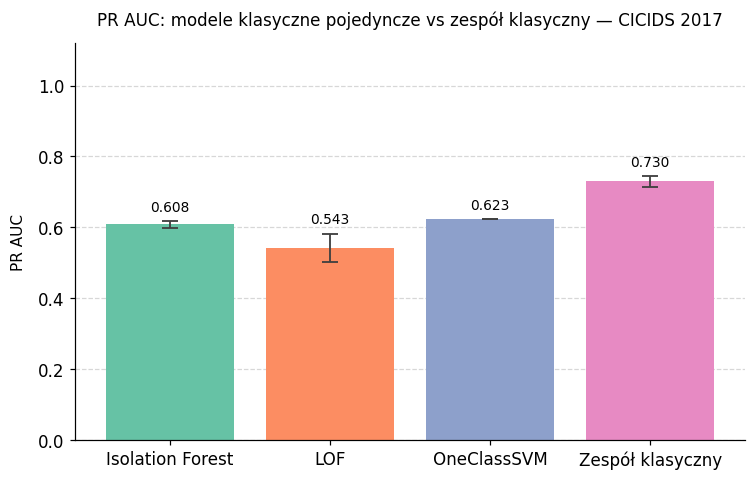

Zapisano: 016_classical_ensemble_unsw_pr_auc.pdf


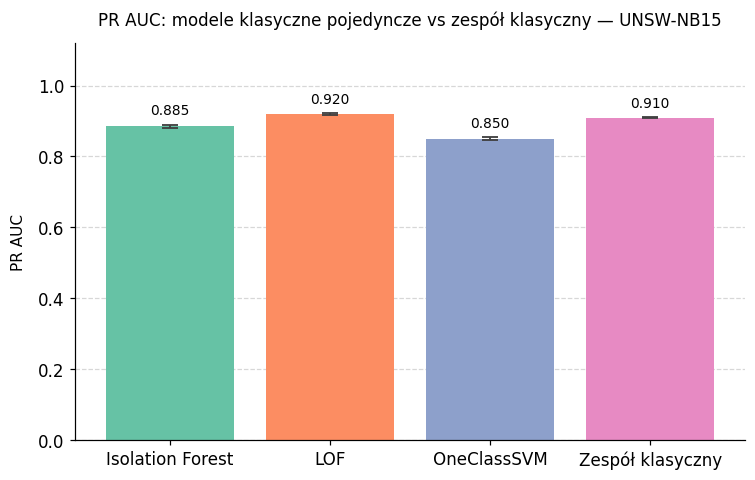

In [144]:
# classical_ensemble_pr_auc.pdf (fig:classical_ensemble_pr_auc)

c_labels = [lab for _, _, lab in CLASSICAL_SPECS]

for dset in DATASETS:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    means, stds = [], []
    
    for mt, fs, _ in CLASSICAL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        a = agg(df_std_clean, mask)
        means.append(a.get("AUC_PR_mean", np.nan))
        stds.append(a.get("AUC_PR_std", np.nan))
    
    rects = ax.bar(
        c_labels, 
        means, 
        yerr=stds, 
        capsize=5, 
        color=COLORS[:len(CLASSICAL_SPECS)], 
        ecolor="#404040", 
        error_kw={"elinewidth": 1.2, "capthick": 1.2}
    )
    
    for rect, mean, std in zip(rects, means, stds):
        if not np.isnan(mean):
            offset = (std if not np.isnan(std) else 0) + 0.02
            ax.text(
                rect.get_x() + rect.get_width() / 2.0, 
                mean + offset, 
                f"{mean:.3f}", 
                ha="center", 
                va="bottom", 
                fontsize=9
            )

    ax.set_ylabel("PR AUC", fontsize=10, labelpad=8)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"PR AUC: modele klasyczne pojedyncze vs zespół klasyczny — {DATASET_LABELS[dset]}", fontsize=11, pad=12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    fig.tight_layout()
    save_fig(fig, f"016_classical_ensemble_{'cicids' if dset=='CICIDS' else 'unsw'}_pr_auc")
    plt.show()

In [ ]:
# Tabela lunar_epochs (tab:lunar_epochs)
METRIC_COLS_EPOCHS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1", "runtime_train"]
METRIC_HEADERS_EPOCHS = {
    "AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
    "Recall": "Recall", "F1": "$F_1$", "runtime_train": "Czas uczenia [s]",
}


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def format_cell(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std) or std == 0:
        return f"${latex_num(mean, nd)}$"
    return f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$"


def build_lunar_epochs_table_latex(df_in, label, caption):
    unique_epochs = sorted(df_in[ep_col].dropna().unique())

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llrrrrrr}", r"\hline",
        "Zbiór & Liczba epok & " + " & ".join(METRIC_HEADERS_EPOCHS[m] for m in METRIC_COLS_EPOCHS) + r" \\",
        r"\hline",
    ]

    for d_idx, dset in enumerate(DATASETS):
        sub_all = df_in[df_in.dataset_name == dset]
        for ep in unique_epochs:
            sub = sub_all[sub_all[ep_col] == ep]
            if sub.empty:
                continue
            cells = [DATASET_LABELS[dset], f"{int(ep)}"]
            for m in METRIC_COLS_EPOCHS:
                nd = 1 if m == "runtime_train" else 3
                mean = sub[m].mean() if m in sub.columns else np.nan
                std = sub[m].std() if m in sub.columns else np.nan
                cells.append(format_cell(mean, std, nd))
            lines.append(" & ".join(cells) + r" \\")
        if d_idx < len(DATASETS) - 1:
            lines.append(r"\hline")

    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


epochs_df = df_std[df_std.model_type == "LUNAR_Epochs_v2"].copy()
ep_col = "hyperparameters.n_epochs"

caption = ("Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; "
           "średnia $\\pm$ odchylenie standardowe z powtórzeń")
label = "tab:lunar_epochs"

tex = build_lunar_epochs_table_latex(epochs_df, label, caption)
print(tex)

fname = "table_lunar_epochs"
with open(FIG_DIR / f"{fname}.tex", "w", encoding="utf-8") as f:
    f.write(tex)

# Podglad pandas / CSV
preview_rows = []
unique_epochs = sorted(epochs_df[ep_col].dropna().unique())
for dset in DATASETS:
    sub_all = epochs_df[epochs_df.dataset_name == dset]
    for ep in unique_epochs:
        sub = sub_all[sub_all[ep_col] == ep]
        if sub.empty:
            continue
        row = {"Zbiór": DATASET_LABELS[dset], "Liczba epok": int(ep)}
        for m in METRIC_COLS_EPOCHS:
            mean = sub[m].mean() if m in sub.columns else np.nan
            std = sub[m].std() if m in sub.columns else np.nan
            if pd.isna(mean):
                row[m] = "--"
            else:
                row[m] = f"{mean:.3f} +/- {std:.3f}" if not pd.isna(std) else f"{mean:.3f}"
        preview_rows.append(row)

df_preview = pd.DataFrame(preview_rows)
display(df_preview)
df_preview.to_csv(FIG_DIR / f"{fname}.csv", index=False)

\begin{table}[H]
\centering
\caption{Wpływ liczby epok na wyniki pojedynczego modelu LUNAR; średnia $\pm$ odchylenie standardowe z powtórzeń}
\label{tab:lunar_epochs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llrrrrrr}
\hline
Zbiór & Liczba epok & ROC AUC & PR AUC & Precision & Recall & $F_1$ & Czas uczenia [s] \\
\hline
CICIDS 2017 & 25 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}002$ & $0{,}637 \pm 0{,}006$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $26{,}2 \pm 5{,}6$ \\
CICIDS 2017 & 50 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}637 \pm 0{,}007$ & $0{,}694 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $46{,}5 \pm 9{,}5$ \\
CICIDS 2017 & 75 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}638 \pm 0{,}009$ & $0{,}693 \pm 0{,}005$ & $0{,}664 \pm 0{,}004$ & $66{,}6 \pm 14{,}6$ \\
CICIDS 2017 & 100 & $0{,}863 \pm 0{,}002$ & $0{,}728 \pm 0{,}003$ & $0{,}643 \pm 0{,}010$ & $0{,}690 \pm 0{,}001$ & $0{,}665 \pm 0{,}005$ & $87{,}1 \pm 18{,}8$ \\
CICIDS 2017 & 150 & $0{,}864

,Zbiór,Liczba epok,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train
0,CICIDS 2017,25,0.863 +/- 0.002,0.728 +/- 0.002,0.637 +/- 0.006,0.694 +/- 0.005,0.664 +/- 0.004,26.209 +/- 5.590
1,CICIDS 2017,50,0.863 +/- 0.002,0.728 +/- 0.003,0.637 +/- 0.007,0.694 +/- 0.005,0.664 +/- 0.004,46.499 +/- 9.503
2,CICIDS 2017,75,0.863 +/- 0.002,0.728 +/- 0.003,0.638 +/- 0.009,0.693 +/- 0.005,0.664 +/- 0.004,66.587 +/- 14.555
3,CICIDS 2017,100,0.863 +/- 0.002,0.728 +/- 0.003,0.643 +/- 0.010,0.690 +/- 0.001,0.665 +/- 0.005,87.098 +/- 18.803
4,CICIDS 2017,150,0.864 +/- 0.002,0.729 +/- 0.004,0.644 +/- 0.012,0.689 +/- 0.001,0.666 +/- 0.006,128.136 +/- 27.985
5,CICIDS 2017,200,0.868 +/- 0.003,0.739 +/- 0.011,0.667 +/- 0.023,0.686 +/- 0.004,0.676 +/- 0.010,187.196 +/- 36.298
6,CICIDS 2017,250,0.870 +/- 0.005,0.744 +/- 0.016,0.659 +/- 0.005,0.703 +/- 0.026,0.680 +/- 0.015,233.095 +/- 46.604
7,CICIDS 2017,300,0.871 +/- 0.006,0.745 +/- 0.015,0.660 +/- 0.003,0.703 +/- 0.027,0.681 +/- 0.014,276.144 +/- 53.336
8,UNSW-NB15,25,0.888 +/- 0.004,0.929 +/- 0.001,0.901 +/- 0.009,0.789 +/- 0.004,0.841 +/- 0.002,52.838 +/- 21.340
9,UNSW-NB15,50,0.888 +/- 0.004,0.929 +/- 0.001,0.899 +/- 0.013,0.790 +/- 0.006,0.841 +/- 0.002,98.810 +/- 41.894


In [108]:
# Tabela classical_ensemble_confusion (tab:classical_ensemble_confusion)
rows = []
for dset in DATASETS:
    for mt, fs, label in CLASSICAL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        sub = df_std_clean[mask]
        rows.append({"Zbior": DATASET_LABELS[dset], "Model": label,
                     "TP": round(sub["ConfusionMatrix_TP"].mean(), 1),
                     "FP": round(sub["ConfusionMatrix_FP"].mean(), 1),
                     "TN": round(sub["ConfusionMatrix_TN"].mean(), 1),
                     "FN": round(sub["ConfusionMatrix_FN"].mean(), 1)})
table_classical_cm = pd.DataFrame(rows)
display(table_classical_cm)
table_classical_cm.to_csv(FIG_DIR / "table_classical_ensemble_confusion.csv", index=False)
with open(FIG_DIR / "table_classical_ensemble_confusion.tex", "w", encoding="utf-8") as f:
    f.write(table_classical_cm.to_latex(index=False,
        caption="Macierze pomylek klasycznych modeli pojedynczych i zespolu klasycznego.",
        label="tab:classical_ensemble_confusion"))

,Zbior,Model,TP,FP,TN,FN
0,CICIDS 2017,Isolation Forest,9708.0,5943.3,54684.7,9664.0
1,CICIDS 2017,LOF,14847.3,10609.0,50019.0,4524.7
2,CICIDS 2017,OneClassSVM,19372.0,60254.7,373.3,0.0
3,CICIDS 2017,Zespol klasyczny,14248.7,5837.3,54790.7,5123.3
4,UNSW-NB15,Isolation Forest,35840.0,10051.7,25900.3,8208.0
5,UNSW-NB15,LOF,35438.3,6328.3,29623.7,8609.7
6,UNSW-NB15,OneClassSVM,33555.3,7917.3,28034.7,10492.7
7,UNSW-NB15,Zespol klasyczny,34387.0,6869.3,29082.7,9661.0


Zapisano: classical_ensemble_fp_fn.pdf


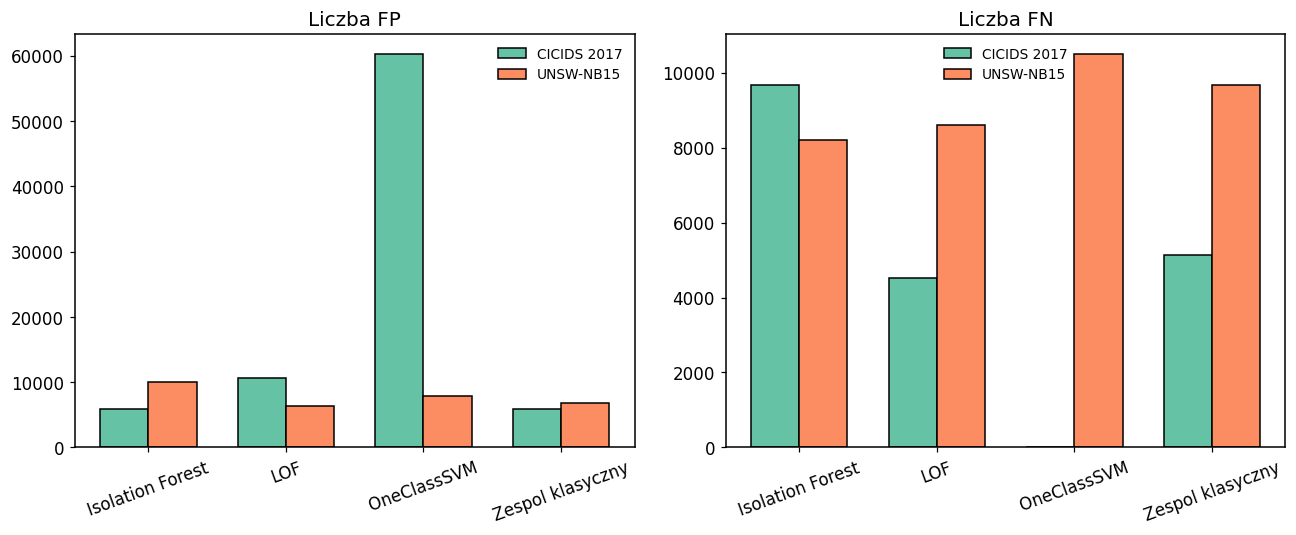

In [109]:
# Wykres classical_ensemble_fp_fn.pdf (fig:classical_ensemble_fp_fn)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
width = 0.35
xpos = np.arange(len(c_labels))
for ax, metric, title in zip(axes, ["ConfusionMatrix_FP", "ConfusionMatrix_FN"], ["FP", "FN"]):
    for j, dset in enumerate(DATASETS):
        vals = []
        for mt, fs, _ in CLASSICAL_SPECS:
            mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
            if fs:
                mask &= (df_std_clean.fusion_strategy == fs)
            vals.append(df_std_clean[mask][metric].mean())
        ax.bar(xpos + (j - 0.5) * width, vals, width, label=DATASET_LABELS[dset], color=COLORS[j], edgecolor="black")
    ax.set_xticks(xpos); ax.set_xticklabels(c_labels, rotation=20)
    ax.set_title(f"Liczba {title}"); ax.legend()
fig.tight_layout()
save_fig(fig, "classical_ensemble_fp_fn")
plt.show()

Zapisano: classical_ensemble_recall_at_fpr.pdf


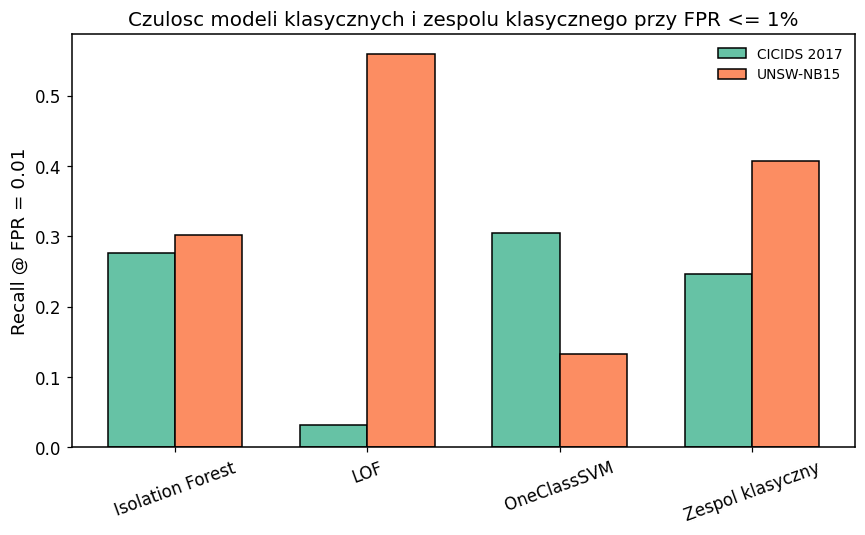

In [110]:
# Wykres classical_ensemble_recall_at_fpr.pdf (fig:classical_ensemble_recall_fpr)
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
xpos = np.arange(len(c_labels))
for j, dset in enumerate(DATASETS):
    vals = []
    for mt, fs, _ in CLASSICAL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        col = "Recall_at_FPR_0.01" if "Recall_at_FPR_0.01" in df_std_clean.columns else None
        vals.append(df_std_clean[mask][col].mean() if col else np.nan)
    ax.bar(xpos + (j - 0.5) * width, vals, width, label=DATASET_LABELS[dset], color=COLORS[j], edgecolor="black")
ax.set_xticks(xpos); ax.set_xticklabels(c_labels, rotation=20)
ax.set_ylabel("Recall @ FPR = 0.01")
ax.set_title("Czulosc modeli klasycznych i zespolu klasycznego przy FPR <= 1%")
ax.legend()
fig.tight_layout()
save_fig(fig, "classical_ensemble_recall_at_fpr")
plt.show()

Zapisano: classical_ensemble_runtime.pdf


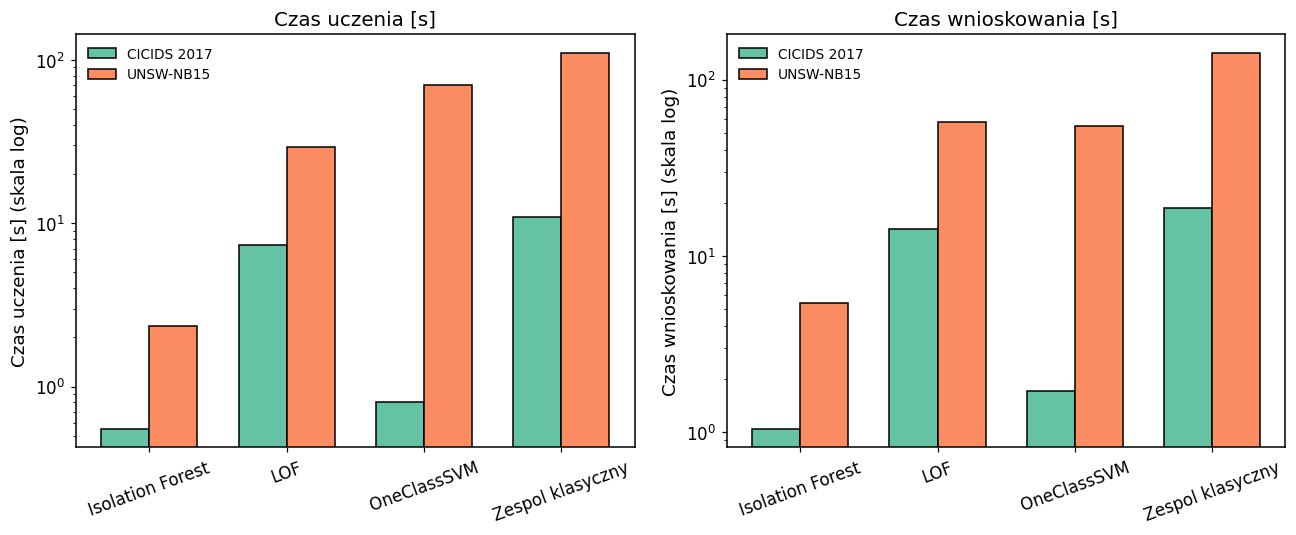

In [111]:
# Wykres classical_ensemble_runtime.pdf (fig:classical_ensemble_runtime)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, title in zip(axes, ["runtime_train", "runtime_inference"], ["Czas uczenia [s]", "Czas wnioskowania [s]"]):
    for j, dset in enumerate(DATASETS):
        vals = []
        for mt, fs, _ in CLASSICAL_SPECS:
            mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
            if fs:
                mask &= (df_std_clean.fusion_strategy == fs)
            vals.append(agg(df_std_clean, mask).get(f"{metric}_mean"))
        ax.bar(xpos + (j - 0.5) * width, vals, width, label=DATASET_LABELS[dset], color=COLORS[j], edgecolor="black")
    ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(c_labels, rotation=20)
    ax.set_ylabel(f"{title} (skala log)"); ax.set_title(title); ax.legend()
fig.tight_layout()
save_fig(fig, "classical_ensemble_runtime")
plt.show()

## Sekcja 4: Ewaluacja klasyfikatorow zespolowych z LUNAR

Pelny zespol (rank mean: LUNAR+IF+LOF+OCSVM) vs LUNAR solo vs zespol klasyczny; warianty progu; koszt.

In [112]:
# Tabela ensemble_lunar_results (tab:ensemble_lunar_results)
rows = []
for dset in DATASETS:
    mask = ((df_std_clean.model_type == "Ensemble_with_LUNAR") &
            (df_std_clean.fusion_strategy == "rank_mean") & (df_std_clean.dataset_name == dset))
    a = agg(df_std_clean, mask)
    rows.append({"Zbior": DATASET_LABELS[dset],
                 "ROC AUC": fmt(a.get("AUC_ROC_mean"), a.get("AUC_ROC_std")),
                 "PR AUC": fmt(a.get("AUC_PR_mean"), a.get("AUC_PR_std")),
                 "Precision": fmt(a.get("Precision_mean"), a.get("Precision_std")),
                 "Recall": fmt(a.get("Recall_mean"), a.get("Recall_std")),
                 "F1": fmt(a.get("F1_mean"), a.get("F1_std")),
                 "Czas uczenia [s]": fmt(a.get("runtime_train_mean"), a.get("runtime_train_std"), 1),
                 "Czas wnioskowania [s]": fmt(a.get("runtime_inference_mean"), a.get("runtime_inference_std"), 1)})
table_ens_lunar = pd.DataFrame(rows)
display(table_ens_lunar)
table_ens_lunar.to_csv(FIG_DIR / "table_ensemble_lunar_results.csv", index=False)
with open(FIG_DIR / "table_ensemble_lunar_results.tex", "w", encoding="utf-8") as f:
    f.write(table_ens_lunar.to_latex(index=False,
        caption="Wyniki pelnego zespolu zawierajacego LUNAR przy progu standardowym.",
        label="tab:ensemble_lunar_results"))

,Zbior,ROC AUC,PR AUC,Precision,Recall,F1,Czas uczenia [s],Czas wnioskowania [s]
0,CICIDS 2017,0.887 +/- 0.002,0.747 +/- 0.011,0.666 +/- 0.020,0.745 +/- 0.007,0.703 +/- 0.008,244.4 +/- 79.9,27.3 +/- 11.8
1,UNSW-NB15,0.892 +/- 0.000,0.925 +/- 0.001,0.803 +/- 0.004,0.839 +/- 0.006,0.820 +/- 0.001,518.3 +/- 155.1,167.2 +/- 3.7


Zapisano: ensemble_lunar_comparison_pr_auc.pdf


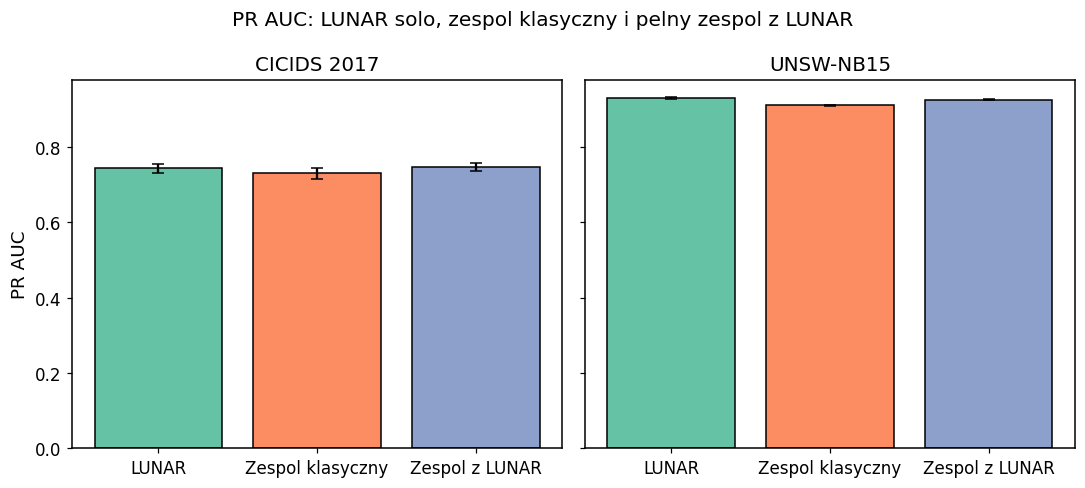

In [113]:
# Wykres ensemble_lunar_comparison_pr_auc.pdf (fig:ensemble_lunar_comparison_pr_auc)
FULL_SPECS = [("LUNAR", None, "LUNAR"), ("Ensemble_without_LUNAR", "rank_mean", "Zespol klasyczny"),
              ("Ensemble_with_LUNAR", "rank_mean", "Zespol z LUNAR")]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, dset in zip(axes, DATASETS):
    means, stds = [], []
    for mt, fs, _ in FULL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        a = agg(df_std_clean, mask)
        means.append(a.get("AUC_PR_mean")); stds.append(a.get("AUC_PR_std"))
    ax.bar([lab for _, _, lab in FULL_SPECS], means, yerr=stds, capsize=4,
           color=COLORS[:len(FULL_SPECS)], edgecolor="black")
    ax.set_title(DATASET_LABELS[dset])
axes[0].set_ylabel("PR AUC")
fig.suptitle("PR AUC: LUNAR solo, zespol klasyczny i pelny zespol z LUNAR")
fig.tight_layout()
save_fig(fig, "ensemble_lunar_comparison_pr_auc")
plt.show()

In [114]:
# Tabela ensemble_lunar_reference (tab:ensemble_lunar_reference)
rows = []
for dset in DATASETS:
    for mt, fs, label in FULL_SPECS:
        mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
        if fs:
            mask &= (df_std_clean.fusion_strategy == fs)
        a = agg(df_std_clean, mask)
        rows.append({"Zbior": DATASET_LABELS[dset], "Wariant": label,
                     "ROC AUC": fmt(a.get("AUC_ROC_mean"), a.get("AUC_ROC_std")),
                     "PR AUC": fmt(a.get("AUC_PR_mean"), a.get("AUC_PR_std")),
                     "Precision": fmt(a.get("Precision_mean"), a.get("Precision_std")),
                     "Recall": fmt(a.get("Recall_mean"), a.get("Recall_std")),
                     "F1": fmt(a.get("F1_mean"), a.get("F1_std"))})
table_ens_ref = pd.DataFrame(rows)
display(table_ens_ref)
table_ens_ref.to_csv(FIG_DIR / "table_ensemble_lunar_reference.csv", index=False)
with open(FIG_DIR / "table_ensemble_lunar_reference.tex", "w", encoding="utf-8") as f:
    f.write(table_ens_ref.to_latex(index=False,
        caption="Porownanie modeli odniesienia i pelnego zespolu z LUNAR przy progu standardowym.",
        label="tab:ensemble_lunar_reference"))

,Zbior,Wariant,ROC AUC,PR AUC,Precision,Recall,F1
0,CICIDS 2017,LUNAR,0.869 +/- 0.004,0.743 +/- 0.013,0.670 +/- 0.020,0.687 +/- 0.001,0.678 +/- 0.010
1,CICIDS 2017,Zespol klasyczny,0.882 +/- 0.002,0.730 +/- 0.015,0.710 +/- 0.020,0.736 +/- 0.024,0.722 +/- 0.003
2,CICIDS 2017,Zespol z LUNAR,0.887 +/- 0.002,0.747 +/- 0.011,0.666 +/- 0.020,0.745 +/- 0.007,0.703 +/- 0.008
3,UNSW-NB15,LUNAR,0.889 +/- 0.005,0.930 +/- 0.002,0.896 +/- 0.006,0.790 +/- 0.002,0.839 +/- 0.002
4,UNSW-NB15,Zespol klasyczny,0.875 +/- 0.001,0.910 +/- 0.000,0.834 +/- 0.008,0.781 +/- 0.014,0.806 +/- 0.004
5,UNSW-NB15,Zespol z LUNAR,0.892 +/- 0.000,0.925 +/- 0.001,0.803 +/- 0.004,0.839 +/- 0.006,0.820 +/- 0.001


Zapisano: ensemble_lunar_pr_curve_cicids.pdf


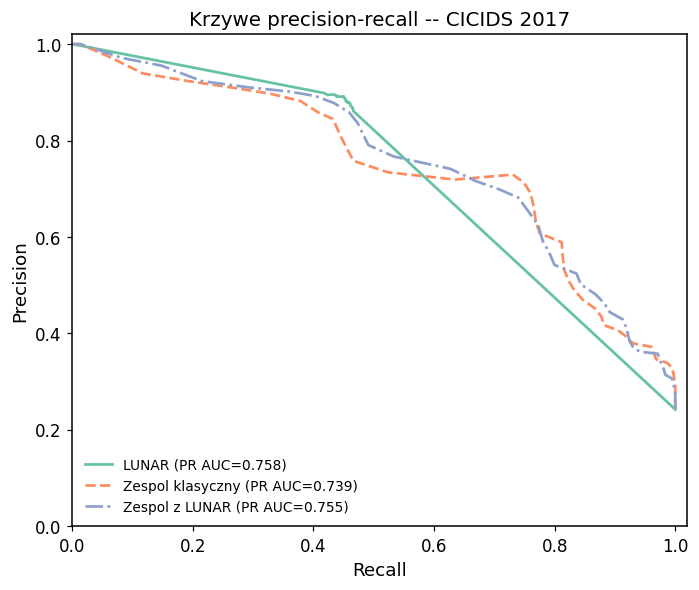

Zapisano: ensemble_lunar_pr_curve_unsw.pdf


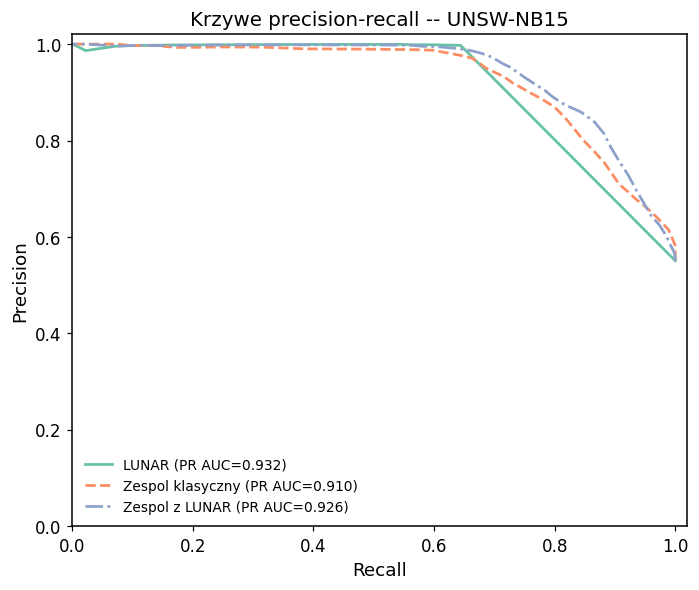

In [115]:
# Wykresy ensemble_lunar_pr_curve_cicids.pdf / ensemble_lunar_pr_curve_unsw.pdf
for dset in DATASETS:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for i, (mt, fs, label) in enumerate(FULL_SPECS):
        curve, aucpr = best_pr_curve(df_std_clean, mt, dset, fs)
        if curve is None:
            continue
        ax.plot(curve["recall"], curve["precision"], color=COLORS[i % len(COLORS)],
                linestyle=LINESTYLES[i % len(LINESTYLES)], linewidth=1.8,
                label=f"{label} (PR AUC={aucpr:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.set_title(f"Krzywe precision-recall -- {DATASET_LABELS[dset]}")
    ax.legend(loc="lower left")
    fig.tight_layout()
    save_fig(fig, f"ensemble_lunar_pr_curve_{'cicids' if dset=='CICIDS' else 'unsw'}")
    plt.show()

In [116]:
# Tabela ensemble_lunar_thresholds (tab:ensemble_lunar_thresholds)
rows = []
for dset in DATASETS:
    for variant, label in [("standard", "Standardowy"), ("recall_oriented", "Zorientowany na czulosc"),
                            ("operational", "Operacyjny")]:
        sub = df[(df.model_type == "Ensemble_with_LUNAR") & (df.fusion_strategy == "rank_mean") &
                 (df.dataset_name == dset) & (df.threshold_variant == variant)]
        rows.append({"Zbior": DATASET_LABELS[dset], "Wariant progu": label,
                     "Precision": f"{sub['Precision'].mean():.3f}" if not sub.empty else "--",
                     "Recall": f"{sub['Recall'].mean():.3f}" if not sub.empty else "--",
                     "F1": f"{sub['F1'].mean():.3f}" if not sub.empty else "--",
                     "FP": round(sub["ConfusionMatrix_FP"].mean(), 1) if not sub.empty else "--",
                     "FN": round(sub["ConfusionMatrix_FN"].mean(), 1) if not sub.empty else "--"})
table_thresholds = pd.DataFrame(rows)
display(table_thresholds)
table_thresholds.to_csv(FIG_DIR / "table_ensemble_lunar_thresholds.csv", index=False)
with open(FIG_DIR / "table_ensemble_lunar_thresholds.tex", "w", encoding="utf-8") as f:
    f.write(table_thresholds.to_latex(index=False,
        caption="Wplyw wariantu progu na dzialanie pelnego zespolu z LUNAR.",
        label="tab:ensemble_lunar_thresholds"))

,Zbior,Wariant progu,Precision,Recall,F1,FP,FN
0,CICIDS 2017,Standardowy,0.666,0.745,0.703,7260.0,4944.7
1,CICIDS 2017,Zorientowany na czulosc,0.463,0.889,0.608,20082.3,2144.7
2,CICIDS 2017,Operacyjny,0.445,0.913,0.598,22096.0,1694.0
3,UNSW-NB15,Standardowy,0.803,0.839,0.820,9065.0,7108.0
4,UNSW-NB15,Zorientowany na czulosc,0.648,0.962,0.774,23142.5,1679.0
5,UNSW-NB15,Operacyjny,0.731,0.898,0.806,14553.0,4506.0


Zapisano: ensemble_lunar_threshold_tradeoff.pdf


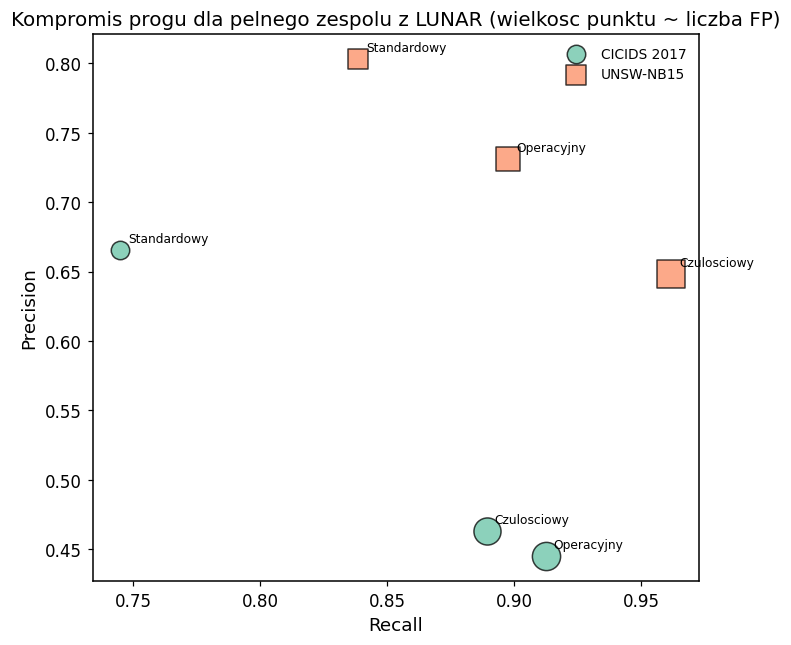

In [117]:
# Wykres ensemble_lunar_threshold_tradeoff.pdf (fig:ensemble_lunar_threshold_tradeoff)
fig, ax = plt.subplots(figsize=(7, 6))
variant_labels = {"standard": "Standardowy", "recall_oriented": "Czulosciowy", "operational": "Operacyjny"}
for i, dset in enumerate(DATASETS):
    for variant, vlabel in variant_labels.items():
        sub = df[(df.model_type == "Ensemble_with_LUNAR") & (df.fusion_strategy == "rank_mean") &
                 (df.dataset_name == dset) & (df.threshold_variant == variant)]
        if sub.empty:
            continue
        rec, prec, fp = sub["Recall"].mean(), sub["Precision"].mean(), sub["ConfusionMatrix_FP"].mean()
        size = 50 + (fp / max(df["ConfusionMatrix_FP"].max(), 1)) * 800
        ax.scatter(rec, prec, s=size, color=COLORS[i], edgecolor="black", alpha=0.75,
                   marker=MARKERS[i], label=DATASET_LABELS[dset] if variant == "standard" else None)
        ax.annotate(vlabel, (rec, prec), fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Kompromis progu dla pelnego zespolu z LUNAR (wielkosc punktu ~ liczba FP)")
ax.legend()
fig.tight_layout()
save_fig(fig, "ensemble_lunar_threshold_tradeoff")
plt.show()

Zapisano: ensemble_lunar_runtime_comparison.pdf


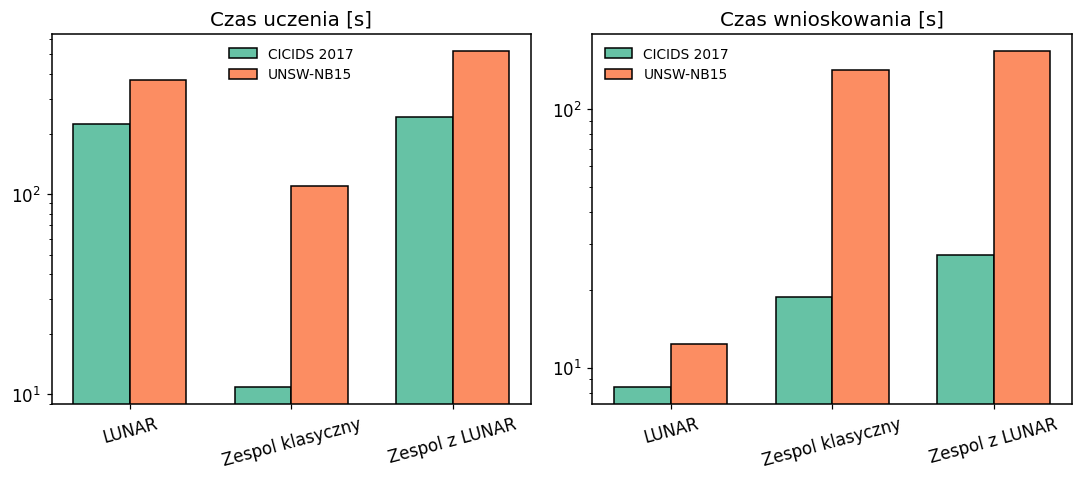

In [118]:
# Wykres ensemble_lunar_runtime_comparison.pdf (fig:ensemble_lunar_runtime)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
f_labels = [lab for _, _, lab in FULL_SPECS]
for ax, metric, title in zip(axes, ["runtime_train", "runtime_inference"], ["Czas uczenia [s]", "Czas wnioskowania [s]"]):
    for j, dset in enumerate(DATASETS):
        vals = []
        for mt, fs, _ in FULL_SPECS:
            mask = (df_std_clean.model_type == mt) & (df_std_clean.dataset_name == dset)
            if fs:
                mask &= (df_std_clean.fusion_strategy == fs)
            vals.append(agg(df_std_clean, mask).get(f"{metric}_mean"))
        xpos = np.arange(len(f_labels)) + (j - 0.5) * 0.35
        ax.bar(xpos, vals, width=0.35, color=COLORS[j], label=DATASET_LABELS[dset], edgecolor="black")
    ax.set_yscale("log")
    ax.set_xticks(np.arange(len(f_labels))); ax.set_xticklabels(f_labels, rotation=15)
    ax.set_title(title); ax.legend()
fig.tight_layout()
save_fig(fig, "ensemble_lunar_runtime_comparison")
plt.show()

## Sekcja 5: Analiza strategii fuzji (LUNAR + LOF)

Fuzja cech, wynikow, decyzji (AND/OR): tabela, PR AUC/F1, krzywe PR, FP/FN dla reguł decyzyjnych.

In [119]:
# Tabela fusion_levels (tab:fusion_levels)
FUSION_SPECS = [("feature_level", "Fuzja cech"), ("score_level", "Fuzja wynikow"),
                ("decision_level_AND", "Decyzja: AND"), ("decision_level_OR", "Decyzja: OR")]

rows = []
for dset in DATASETS:
    for fs, label in FUSION_SPECS:
        mask = ((df_std_clean.model_type == "Fusion_Level_Comparison") &
                (df_std_clean.fusion_strategy == fs) & (df_std_clean.dataset_name == dset))
        a = agg(df_std_clean, mask)
        recall_fpr = df_std_clean[mask]["Recall_at_FPR_0.01"].mean() if "Recall_at_FPR_0.01" in df_std_clean.columns else np.nan
        rows.append({"Zbior": DATASET_LABELS[dset], "Poziom fuzji": label,
                     "ROC AUC": fmt(a.get("AUC_ROC_mean"), a.get("AUC_ROC_std")),
                     "PR AUC": fmt(a.get("AUC_PR_mean"), a.get("AUC_PR_std")),
                     "Precision": fmt(a.get("Precision_mean"), a.get("Precision_std")),
                     "Recall": fmt(a.get("Recall_mean"), a.get("Recall_std")),
                     "F1": fmt(a.get("F1_mean"), a.get("F1_std")),
                     "Recall@FPR=0.01": f"{recall_fpr:.3f}" if not pd.isna(recall_fpr) else "--"})
table_fusion = pd.DataFrame(rows)
display(table_fusion)
table_fusion.to_csv(FIG_DIR / "table_fusion_levels.csv", index=False)
with open(FIG_DIR / "table_fusion_levels.tex", "w", encoding="utf-8") as f:
    f.write(table_fusion.to_latex(index=False,
        caption="Porownanie poziomow fuzji LUNAR i LOF przy progu standardowym.", label="tab:fusion_levels"))

,Zbior,Poziom fuzji,ROC AUC,PR AUC,Precision,Recall,F1,Recall@FPR=0.01
0,CICIDS 2017,Fuzja cech,0.960 +/- 0.000,0.882 +/- 0.002,0.794 +/- 0.001,0.842 +/- 0.010,0.817 +/- 0.005,0.440
1,CICIDS 2017,Fuzja wynikow,0.894 +/- 0.004,0.683 +/- 0.016,0.696 +/- 0.046,0.840 +/- 0.029,0.760 +/- 0.017,0.066
2,CICIDS 2017,Decyzja: AND,0.751 +/- 0.038,0.520 +/- 0.053,0.727 +/- 0.029,0.570 +/- 0.077,0.638 +/- 0.057,0.084
3,CICIDS 2017,Decyzja: OR,0.834 +/- 0.014,0.530 +/- 0.024,0.568 +/- 0.025,0.884 +/- 0.020,0.691 +/- 0.020,0.041
4,UNSW-NB15,Fuzja cech,0.950 +/- 0.004,0.963 +/- 0.002,0.811 +/- 0.003,0.923 +/- 0.018,0.863 +/- 0.008,0.716
5,UNSW-NB15,Fuzja wynikow,0.904 +/- 0.004,0.933 +/- 0.002,0.834 +/- 0.073,0.809 +/- 0.055,0.818 +/- 0.004,0.638
6,UNSW-NB15,Decyzja: AND,0.833 +/- 0.002,0.827 +/- 0.004,0.921 +/- 0.007,0.745 +/- 0.004,0.824 +/- 0.001,0.096
7,UNSW-NB15,Decyzja: OR,0.820 +/- 0.003,0.790 +/- 0.004,0.832 +/- 0.006,0.849 +/- 0.007,0.840 +/- 0.002,0.040


Zapisano: fusion_levels_pr_auc_f1.pdf


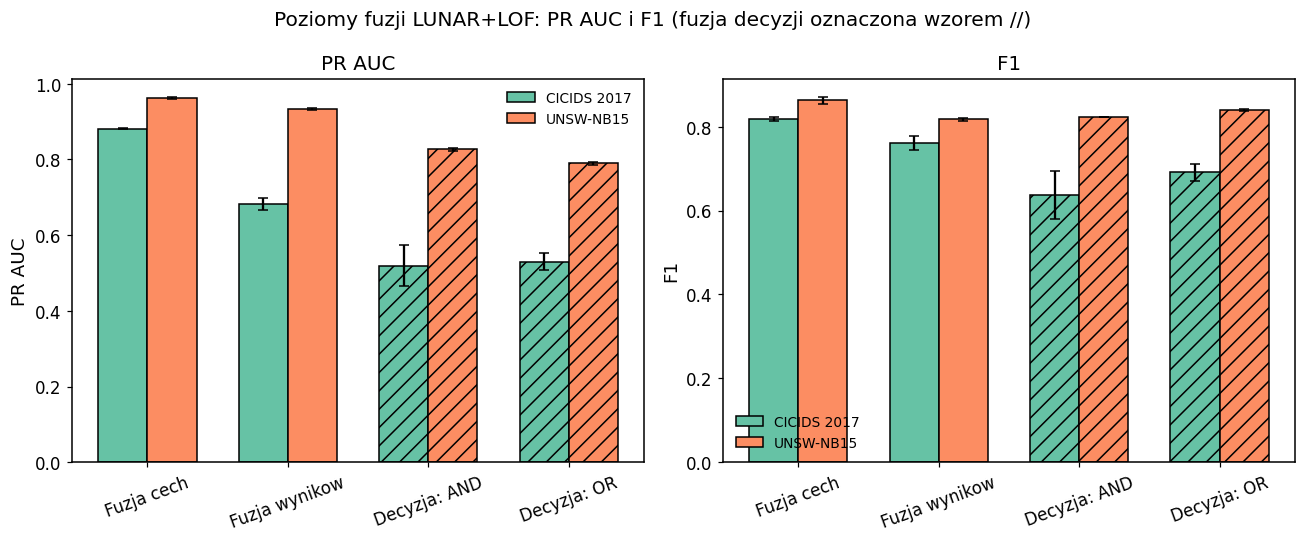

In [120]:
# Wykres fusion_levels_pr_auc_f1.pdf (fig:fusion_levels_pr_auc_f1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
f_labels2 = [lab for _, lab in FUSION_SPECS]
hatches = ["", "", "//", "//"]  # decyzja: inny wzor wypelnienia (nie zachowuje ciaglego rankingu)
for ax, metric, title in zip(axes, ["AUC_PR", "F1"], ["PR AUC", "F1"]):
    width = 0.35
    xpos = np.arange(len(f_labels2))
    for j, dset in enumerate(DATASETS):
        means, stds = [], []
        for fs, _ in FUSION_SPECS:
            mask = ((df_std_clean.model_type == "Fusion_Level_Comparison") &
                    (df_std_clean.fusion_strategy == fs) & (df_std_clean.dataset_name == dset))
            a = agg(df_std_clean, mask)
            means.append(a.get(f"{metric}_mean")); stds.append(a.get(f"{metric}_std"))
        bars = ax.bar(xpos + (j - 0.5) * width, means, width, yerr=stds, capsize=3,
                       color=COLORS[j], label=DATASET_LABELS[dset], edgecolor="black")
        for bar, h in zip(bars, hatches):
            bar.set_hatch(h)
    ax.set_xticks(xpos); ax.set_xticklabels(f_labels2, rotation=20)
    ax.set_ylabel(title); ax.set_title(title); ax.legend()
fig.suptitle("Poziomy fuzji LUNAR+LOF: PR AUC i F1 (fuzja decyzji oznaczona wzorem //)")
fig.tight_layout()
save_fig(fig, "fusion_levels_pr_auc_f1")
plt.show()

Zapisano: fusion_levels_precision_recall_cicids.pdf


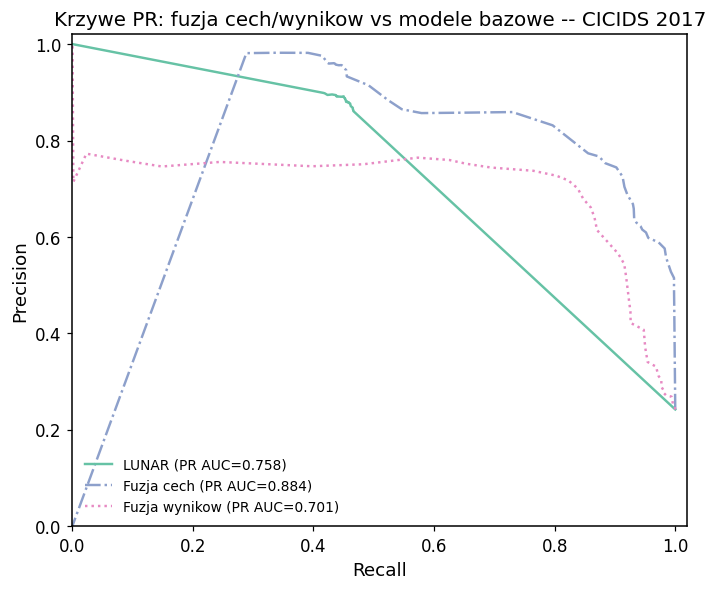

Zapisano: fusion_levels_precision_recall_unsw.pdf


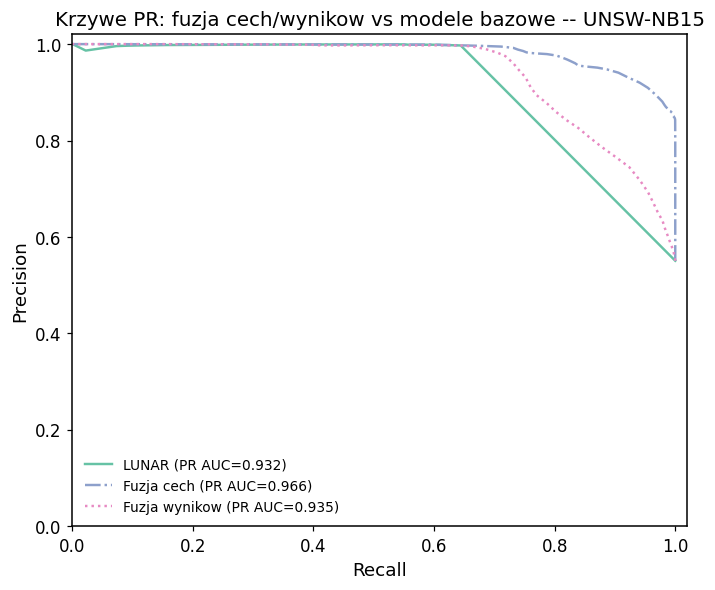

In [121]:
# Wykres fusion_levels_precision_recall.pdf (fig:fusion_levels_pr_curve)
for dset in DATASETS:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    curves_spec = [("LUNAR", None, "LUNAR"), ("LOF", None, "LOF"),
                   ("Fusion_Level_Comparison", "feature_level", "Fuzja cech"),
                   ("Fusion_Level_Comparison", "score_level", "Fuzja wynikow")]
    for i, (mt, fs, label) in enumerate(curves_spec):
        curve, aucpr = best_pr_curve(df_std_clean, mt, dset, fs)
        if curve is None:
            continue
        ax.plot(curve["recall"], curve["precision"], color=COLORS[i % len(COLORS)],
                linestyle=LINESTYLES[i % len(LINESTYLES)], linewidth=1.6,
                label=f"{label} (PR AUC={aucpr:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
    ax.set_title(f"Krzywe PR: fuzja cech/wynikow vs modele bazowe -- {DATASET_LABELS[dset]}")
    ax.legend(loc="lower left")
    fig.tight_layout()
    save_fig(fig, f"fusion_levels_precision_recall_{'cicids' if dset=='CICIDS' else 'unsw'}")
    plt.show()

Zapisano: fusion_decision_fp_fn.pdf


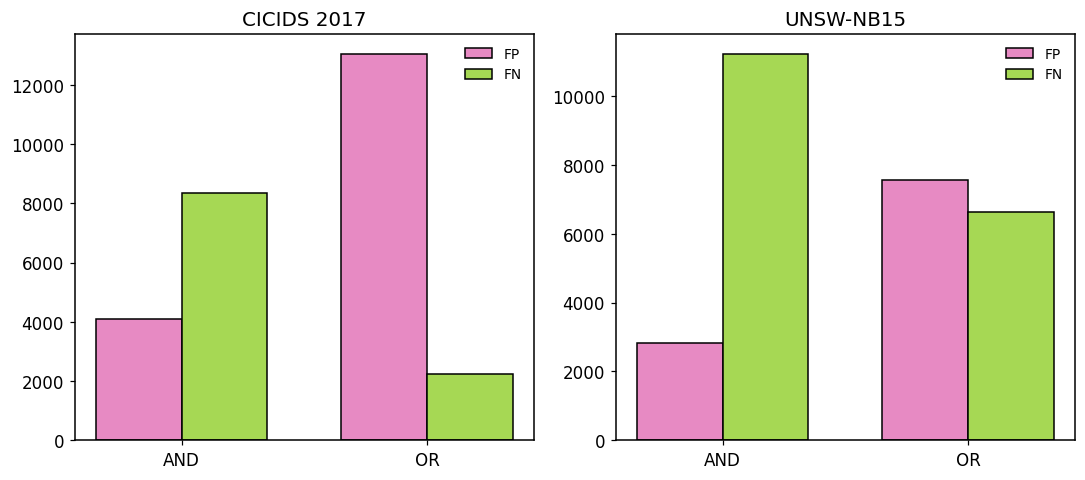

In [122]:
# Wykres fusion_decision_fp_fn.pdf (fig:fusion_decision_fp_fn)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
width = 0.35
xpos = np.arange(2)
for ax, dset in zip(axes, DATASETS):
    fps, fns = [], []
    for fs in ["decision_level_AND", "decision_level_OR"]:
        sub = df_std_clean[(df_std_clean.model_type == "Fusion_Level_Comparison") &
                           (df_std_clean.fusion_strategy == fs) & (df_std_clean.dataset_name == dset)]
        fps.append(sub["ConfusionMatrix_FP"].mean())
        fns.append(sub["ConfusionMatrix_FN"].mean())
    ax.bar(xpos - width/2, fps, width, label="FP", color=COLORS[3], edgecolor="black")
    ax.bar(xpos + width/2, fns, width, label="FN", color=COLORS[4], edgecolor="black")
    ax.set_xticks(xpos); ax.set_xticklabels(["AND", "OR"])
    ax.set_title(DATASET_LABELS[dset]); ax.legend()
fig.tight_layout()
save_fig(fig, "fusion_decision_fp_fn")
plt.show()

## Sekcja 6: Analiza odpornosci

Zmiana udzialu atakow (imbalance), szum cech, dropout cech -- LUNAR+LOF (rank mean, Robustness_Analysis)
vs homogeniczny zespol LUNAR (bagging).

Zapisano: robustness_imbalance_pr_auc_f1.pdf


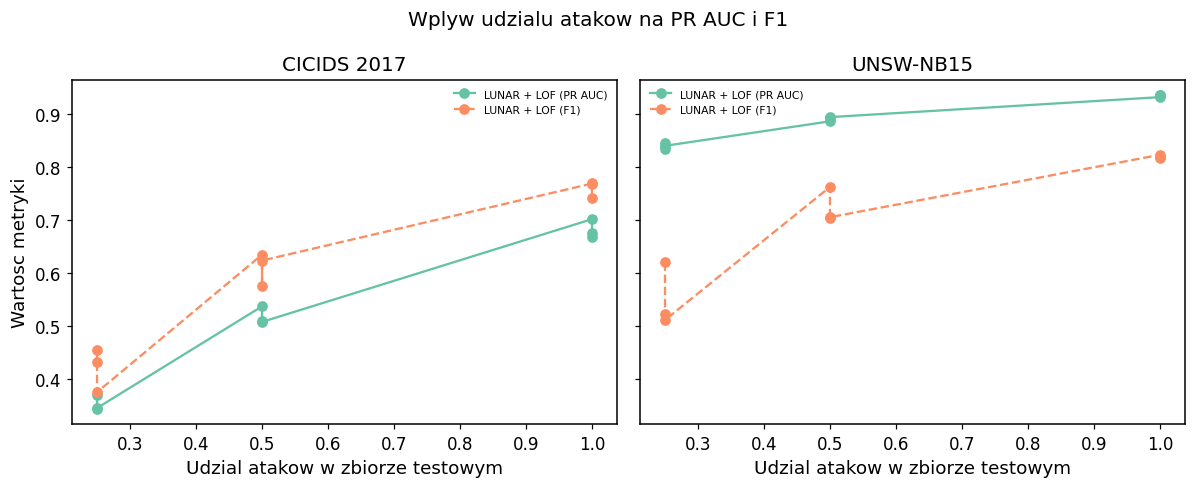

In [123]:
ROBUST_SPECS = [("Robustness_Analysis", "rank_mean", "LUNAR + LOF"),
                ("LUNAR_Self_Ensemble", "bagging", "LUNAR self-ensemble (bagging)")]

def robust_series(mt, fs, dset, param_col):
    sub = df_std[(df_std.model_type == mt) & (df_std.fusion_strategy == fs) & (df_std.dataset_name == dset)]
    if param_col not in sub.columns:
        return pd.DataFrame(columns=[param_col, "AUC_PR", "F1", "Precision", "Recall", "ConfusionMatrix_FP"])
    sub = sub.dropna(subset=[param_col]).sort_values(param_col)
    return sub

# Wykres robustness_imbalance_pr_auc_f1.pdf (fig:robustness_imbalance)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, dset in zip(axes, DATASETS):
    for i, (mt, fs, label) in enumerate(ROBUST_SPECS):
        sub = robust_series(mt, fs, dset, "hyperparameters.imbalance_factor_test")
        if sub.empty:
            continue
        ax.plot(sub["hyperparameters.imbalance_factor_test"], sub["AUC_PR"], marker=MARKERS[i],
                linestyle="-", color=COLORS[i*2], label=f"{label} (PR AUC)")
        ax.plot(sub["hyperparameters.imbalance_factor_test"], sub["F1"], marker=MARKERS[i],
                linestyle="--", color=COLORS[i*2+1], label=f"{label} (F1)")
    ax.set_xlabel("Udzial atakow w zbiorze testowym")
    ax.set_title(DATASET_LABELS[dset]); ax.legend(fontsize=7)
axes[0].set_ylabel("Wartosc metryki")
fig.suptitle("Wplyw udzialu atakow na PR AUC i F1")
fig.tight_layout()
save_fig(fig, "robustness_imbalance_pr_auc_f1")
plt.show()

Zapisano: robustness_noise_metrics.pdf


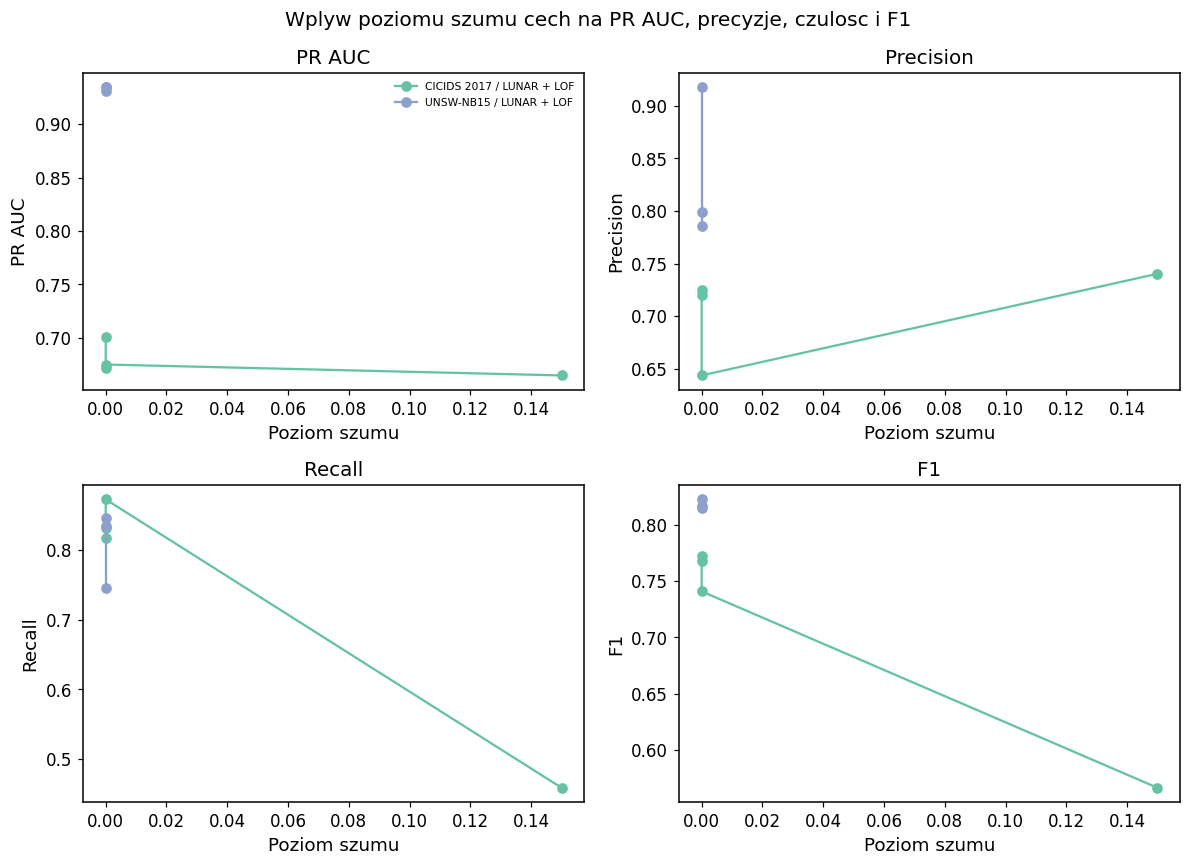

In [124]:
# Wykres robustness_noise_metrics.pdf (fig:robustness_noise_metrics)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics_panels = [("AUC_PR", "PR AUC"), ("Precision", "Precision"), ("Recall", "Recall"), ("F1", "F1")]
for ax, (metric, mlabel) in zip(axes.flat, metrics_panels):
    for dset in DATASETS:
        for i, (mt, fs, label) in enumerate(ROBUST_SPECS):
            sub = robust_series(mt, fs, dset, "hyperparameters.noise")
            if sub.empty:
                continue
            ax.plot(sub["hyperparameters.noise"], sub[metric], marker=MARKERS[i],
                    color=COLORS[DATASETS.index(dset)*2 + i], linestyle=LINESTYLES[i],
                    label=f"{DATASET_LABELS[dset]} / {label}")
    ax.set_xlabel("Poziom szumu"); ax.set_ylabel(mlabel); ax.set_title(mlabel)
axes[0, 0].legend(fontsize=7, loc="best")
fig.suptitle("Wplyw poziomu szumu cech na PR AUC, precyzje, czulosc i F1")
fig.tight_layout()
save_fig(fig, "robustness_noise_metrics")
plt.show()

Zapisano: robustness_feature_dropout.pdf


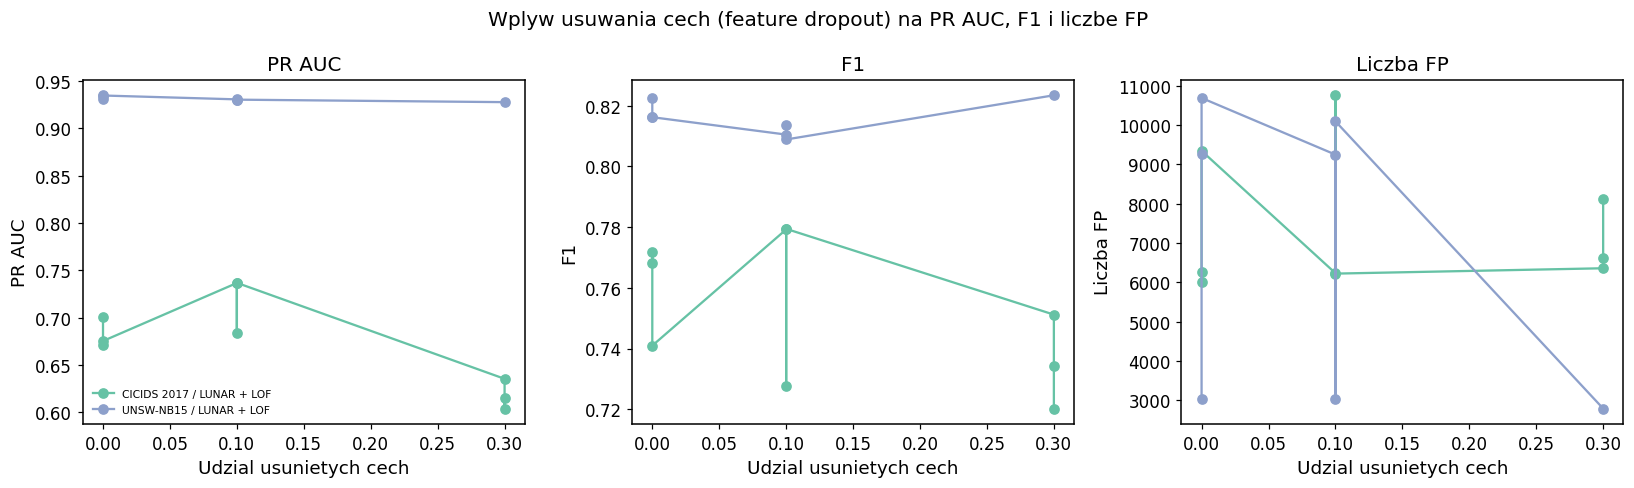

In [125]:
# Wykres robustness_feature_dropout.pdf (fig:robustness_feature_dropout)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [("AUC_PR", "PR AUC"), ("F1", "F1"), ("ConfusionMatrix_FP", "Liczba FP")]
for ax, (metric, mlabel) in zip(axes, panels):
    for dset in DATASETS:
        for i, (mt, fs, label) in enumerate(ROBUST_SPECS):
            sub = robust_series(mt, fs, dset, "hyperparameters.feature_dropout")
            if sub.empty:
                continue
            ax.plot(sub["hyperparameters.feature_dropout"], sub[metric], marker=MARKERS[i],
                    color=COLORS[DATASETS.index(dset)*2 + i], linestyle=LINESTYLES[i],
                    label=f"{DATASET_LABELS[dset]} / {label}")
    ax.set_xlabel("Udzial usunietych cech"); ax.set_ylabel(mlabel); ax.set_title(mlabel)
axes[0].legend(fontsize=7)
fig.suptitle("Wplyw usuwania cech (feature dropout) na PR AUC, F1 i liczbe FP")
fig.tight_layout()
save_fig(fig, "robustness_feature_dropout")
plt.show()

In [126]:
# Tabela robustness_results (tab:robustness_results)
rows = []
param_specs = [("hyperparameters.noise", "Szum"), ("hyperparameters.feature_dropout", "Dropout cech"),
               ("hyperparameters.imbalance_factor_test", "Nierownowaga")]
for dset in DATASETS:
    for mt, fs, label in ROBUST_SPECS:
        for param_col, param_label in param_specs:
            sub = robust_series(mt, fs, dset, param_col)
            for _, r in sub.iterrows():
                rows.append({"Zbior": DATASET_LABELS[dset], "Wariant": label, "Zaburzenie": param_label,
                             "Poziom": r[param_col], "PR AUC": f"{r['AUC_PR']:.3f}", "F1": f"{r['F1']:.3f}",
                             "FP": round(r["ConfusionMatrix_FP"], 1)})
table_robust = pd.DataFrame(rows).sort_values(["Zbior", "Wariant", "Zaburzenie", "Poziom"])
display(table_robust)
table_robust.to_csv(FIG_DIR / "table_robustness_results.csv", index=False)
with open(FIG_DIR / "table_robustness_results.tex", "w", encoding="utf-8") as f:
    f.write(table_robust.to_latex(index=False,
        caption="Plan raportowania wynikow analizy odpornosci (PR AUC, F1, FP dla kazdego poziomu zaburzenia).",
        label="tab:robustness_results"))

,Zbior,Wariant,Zaburzenie,Poziom,PR AUC,F1,FP
4,CICIDS 2017,LUNAR + LOF,Dropout cech,0.00,0.701,0.768,5998
5,CICIDS 2017,LUNAR + LOF,Dropout cech,0.00,0.672,0.772,6251
6,CICIDS 2017,LUNAR + LOF,Dropout cech,0.00,0.675,0.741,9343
7,CICIDS 2017,LUNAR + LOF,Dropout cech,0.10,0.737,0.779,6232
8,CICIDS 2017,LUNAR + LOF,Dropout cech,0.10,0.684,0.728,10756
9,CICIDS 2017,LUNAR + LOF,Dropout cech,0.10,0.737,0.779,6221
10,CICIDS 2017,LUNAR + LOF,Dropout cech,0.30,0.636,0.751,6357
11,CICIDS 2017,LUNAR + LOF,Dropout cech,0.30,0.604,0.734,6608
12,CICIDS 2017,LUNAR + LOF,Dropout cech,0.30,0.615,0.720,8130
13,CICIDS 2017,LUNAR + LOF,Nierownowaga,0.25,0.370,0.453,9483
